# **AI-Powered Demand & Inventory Intelligence Platform**



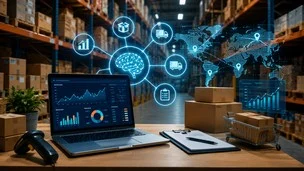

## **Problem Statement**

In modern retail and e-commerce, businesses often struggle to accurately predict product demand and maintain optimal inventory levels. Traditional inventory management methods rely heavily on historical averages and manual decisions, which can lead to overstocking, stockouts, increased holding costs, and lost sales.

 The proposed AI-Powered Demand & Inventory Intelligence Platform addresses this challenge by using machine learning and time-series forecasting to analyze historical sales, inventory levels, product trends, seasonality, promotions, and other relevant factors.

The system aims to:

* 📊 Forecast future product demand using ML and time-series models.
* 📦 Optimize inventory levels and recommend appropriate replenishment quantities.
* ⚠️ Identify stockout and overstock risks before they occur.
* 🎯 Compare multiple forecasting models such as XGBoost, LightGBM, Random Forest, Prophet, ARIMA/SARIMA, etc.
* 📈 Evaluate model performance using suitable forecasting metrics.
* 🧠Generate risk scores and actionable recommendations for inventory decisions.
* 🖥️ Provide an interactive Streamlit dashboard for monitoring demand, inventory health, forecasts, and alerts.
* ☁️ Deploy the solution so that it can support real-world business decision-making.

## **Project Objective**

The primary objective of Project FORESIGHT – AI-Powered Demand & Inventory Intelligence Platform is to develop an intelligent system that uses Machine Learning and Time-Series Forecasting to predict future product demand and optimize inventory management.

### **Key Objectives**
**Demand Forecasting** – Predict future sales demand using historical sales and business-related data.

**Data Cleaning & EDA**– Clean, transform, and explore the dataset to identify trends, seasonality, patterns, and anomalies.

**Feature Engineering**– Create meaningful features such as lag values, rolling averages, seasonal indicators, and demand trends.

**Model **bold text** Development** – Build and compare models such as XGBoost, LightGBM, Random Forest, Prophet, ARIMA/SARIMA, and other suitable forecasting approaches.

**Model Evaluation** – Evaluate forecasting accuracy using metrics such as MAE, RMSE, MAPE, and R² where appropriate.

**Inventory Optimization** – Determine optimal inventory levels and generate replenishment recommendations.

**Risk Scoring** – Identify and score stockout, overstock, and demand volatility risks.

**Interactive Dashboard** – Develop a Streamlit dashboard to visualize forecasts, inventory health, risk alerts, and recommendations.

**Business Decision Support** – Convert predictions into actionable insights that help reduce stockouts, excess inventory, and inventory holding costs.

**Deployment** – Deploy the complete platform so it can be accessed and used for real-time inventory monitoring and decision-making.

### **Dataset Description**

For Project FORESIGHT – AI-Powered Demand & Inventory Intelligence Platform, the dataset is an online retail transaction dataset containing sales records from two financial years: 2009–2010 and 2010–2011.

The dataset contains 1,067,371 transaction records across 8 features, providing information about products, quantities sold, transaction dates, prices, customers, and countries.


 | Attribute       | Description                        |
| --------------- | ---------------------------------- |
| **Invoice**     | Unique invoice/transaction number  |
| **StockCode**   | Unique product identification code |
| **Description** | Name/description of the product    |
| **Quantity**    | Number of units purchased          |
| **InvoiceDate** | Date and time of the transaction   |
| **Price**       | Unit price of the product          |
| **Customer ID** | Unique customer identifier         |
| **Country**     | Customer's country                 |


### **Important Features**

The dataset contains 8 important features that are used to understand sales behavior and build the demand forecasting system. The provided Excel file has two sheets—Year 2009–2010 and Year 2010–2011—with the same feature structure.

Feature	Type	Importance in Project
Invoice	Categorical	Identifies each transaction
StockCode	Categorical	Identifies the product/SKU
Description	Text	Provides product information
Quantity	Numerical	Main demand/sales quantity used for forecasting
InvoiceDate	Date-Time	Captures time-based demand, trends and seasonality
Price	Numerical	Helps analyze pricing and revenue patterns
Customer ID	Categorical	Helps understand customer purchasing behavior
Country	Categorical	Enables geographical demand analysis
Most Important Features for Forecasting

1. Quantity – Target variable representing the number of units sold.

2. InvoiceDate – Used to create daily, weekly, and monthly demand patterns.

3. StockCode – Enables product-level/SKU-level forecasting.

4. Price – Helps identify the relationship between pricing and demand.

5. Customer ID – Useful for customer purchasing and repeat-demand analysis.

6. Country – Useful for identifying geographical demand variations.

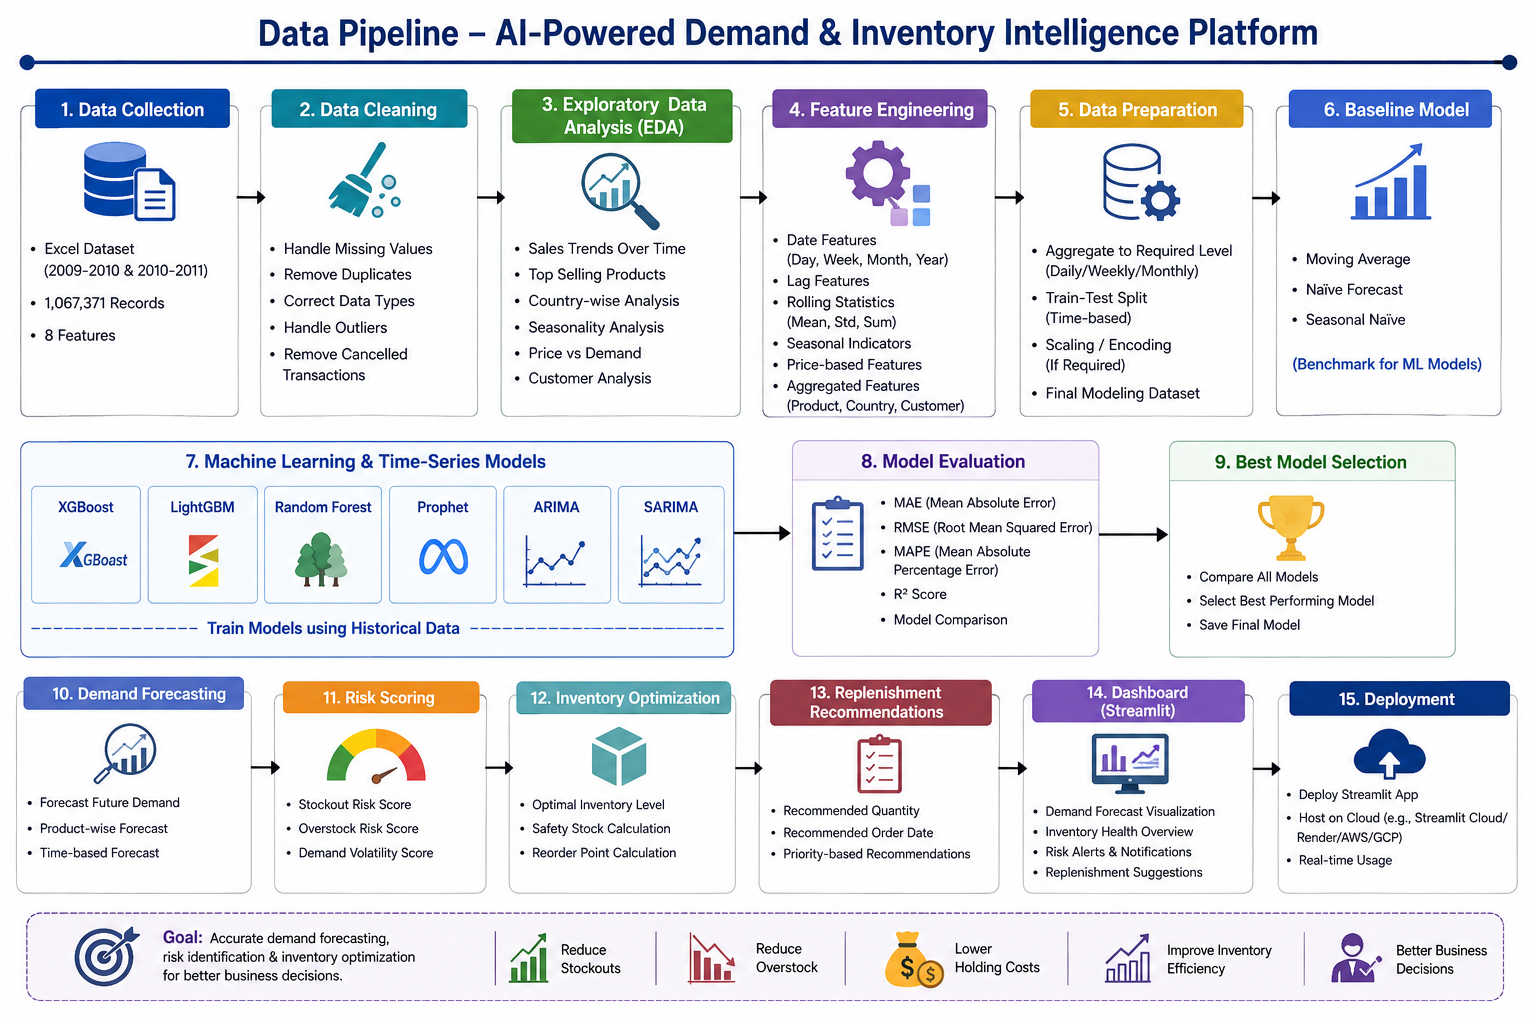

## **Task 1 — Data Loading, Merging & Deep Exploration**

### **Step 1 — Install / Import Required Libraries**

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from datetime import datetime

print("Libraries imported successfully!")

Libraries imported successfully!


### **Step 2 — Upload Dataset**

In [12]:
from google.colab import files

uploaded = files.upload()

print("Dataset uploaded successfully!")

Saving Dataset.xlsx to Dataset (2).xlsx
Dataset uploaded successfully!


In [13]:
file_name = "Dataset.xlsx"

excel_file = pd.ExcelFile(file_name)

print("Available sheets:")
print(excel_file.sheet_names)

Available sheets:
['Year 2009-2010', 'Year 2010-2011']


In [14]:
df_2009_2010 = pd.read_excel(
    file_name,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_name,
    sheet_name="Year 2010-2011"
)

print("2009-2010 shape:", df_2009_2010.shape)
print("2010-2011 shape:", df_2010_2011.shape)

2009-2010 shape: (525461, 8)
2010-2011 shape: (541910, 8)


In [15]:

print("2009-2010 Dataset:")
display(df_2009_2010.head())

print("\n2010-2011 Dataset:")
display(df_2010_2011.head())

2009-2010 Dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



2010-2011 Dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
print("Columns in 2009-2010:")
print(df_2009_2010.columns.tolist())

print("\nColumns in 2010-2011:")
print(df_2010_2011.columns.tolist())


Columns in 2009-2010:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Columns in 2010-2011:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [17]:

df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1067371, 8)


In [18]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [19]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371.0,53628.0,537434.0,1350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.0,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445


In [21]:

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

display(missing_summary)

,Missing Values,Missing Percentage
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [22]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 34335


In [23]:
data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

display(data_types)

,Column,Data Type
Invoice,Invoice,object
StockCode,StockCode,object
Description,Description,object
Quantity,Quantity,int64
InvoiceDate,InvoiceDate,datetime64[ns]
Price,Price,float64
Customer ID,Customer ID,float64
Country,Country,object


In [24]:

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

print(df["InvoiceDate"].dtype)

datetime64[ns]


In [25]:
print("Minimum Invoice Date:")
print(df["InvoiceDate"].min())

print("\nMaximum Invoice Date:")
print(df["InvoiceDate"].max())

Minimum Invoice Date:
2009-12-01 07:45:00

Maximum Invoice Date:
2011-12-09 12:50:00


In [26]:
df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

df["Customer ID"] = pd.to_numeric(
    df["Customer ID"],
    errors="coerce"
)

print("Numeric conversion completed.")

Numeric conversion completed.


In [27]:
df["Revenue"] = df["Quantity"] * df["Price"]

display(
    df[
        [
            "Invoice",
            "Quantity",
            "Price",
            "Revenue"
        ]
    ].head()
)

,Invoice,Quantity,Price,Revenue
0,489434,12,6.95,83.4
1,489434,12,6.75,81.0
2,489434,12,6.75,81.0
3,489434,48,2.10,100.8
4,489434,24,1.25,30.0


In [28]:

df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["Month_Name"] = df["InvoiceDate"].dt.month_name()

df["Day"] = df["InvoiceDate"].dt.day

df["Day_Name"] = df["InvoiceDate"].dt.day_name()

df["Week"] = df["InvoiceDate"].dt.isocalendar().week

df["Quarter"] = df["InvoiceDate"].dt.quarter

df["Date"] = df["InvoiceDate"].dt.date

display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Day,Day_Name,Week,Quarter,Date
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday,49,4,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,49,4,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,49,4,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,1,Tuesday,49,4,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,1,Tuesday,49,4,2009-12-01


In [29]:

cancelled_transactions = df[
    df["Invoice"].astype(str).str.startswith("C")
]

print(
    "Cancelled transactions:",
    len(cancelled_transactions)
)

Cancelled transactions: 19494


In [30]:
negative_quantity = df[
    df["Quantity"] <= 0
]

print(
    "Transactions with Quantity <= 0:",
    len(negative_quantity)
)

Transactions with Quantity <= 0: 22950


In [31]:
invalid_price = df[
    df["Price"] <= 0
]

print(
    "Transactions with Price <= 0:",
    len(invalid_price)
)

Transactions with Price <= 0: 6207


In [32]:

df_clean = df.copy()

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]

# Remove invalid quantities
df_clean = df_clean[
    df_clean["Quantity"] > 0
]

# Remove invalid prices
df_clean = df_clean[
    df_clean["Price"] > 0
]

# Remove rows without InvoiceDate
df_clean = df_clean.dropna(
    subset=["InvoiceDate"]
)

print(
    "Original rows:",
    len(df)
)

print(
    "Cleaned rows:",
    len(df_clean)
)

Original rows: 1067371
Cleaned rows: 1007913


In [33]:

df_clean["Revenue"] = (
    df_clean["Quantity"] *
    df_clean["Price"]
)

print(
    "Total Revenue:",
    round(df_clean["Revenue"].sum(), 2)
)

Total Revenue: 20476260.45


In [34]:
print("Final Dataset Shape:")
print(df_clean.shape)

print("\nFinal Dataset Columns:")
print(df_clean.columns.tolist())

print("\nFinal Dataset Information:")
df_clean.info()

Final Dataset Shape:
(1007913, 17)

Final Dataset Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Day', 'Day_Name', 'Week', 'Quarter', 'Date']

Final Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 1007913 entries, 0 to 1067370
Data columns (total 17 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1007913 non-null  object        
 1   StockCode    1007913 non-null  object        
 2   Description  1007913 non-null  object        
 3   Quantity     1007913 non-null  int64         
 4   InvoiceDate  1007913 non-null  datetime64[ns]
 5   Price        1007913 non-null  float64       
 6   Customer ID  779425 non-null   float64       
 7   Country      1007913 non-null  object        
 8   Revenue      1007913 non-null  float64       
 9   Year         1007913 non-null  int32         
 10

In [35]:
final_missing = df_clean.isnull().sum()

display(
    final_missing[
        final_missing > 0
    ].sort_values(
        ascending=False
    )
)

,0
Customer ID,228488


In [36]:
total_revenue = df_clean["Revenue"].sum()

total_units = df_clean["Quantity"].sum()

total_orders = df_clean["Invoice"].nunique()

total_customers = df_clean["Customer ID"].nunique()

total_products = df_clean["StockCode"].nunique()

total_countries = df_clean["Country"].nunique()

print("============================================")
print(" SALES FORECASTING & DEMAND INTELLIGENCE")
print("============================================")

print(
    f"Total Revenue     : £{total_revenue:,.2f}"
)

print(
    f"Total Units Sold  : {total_units:,.0f}"
)

print(
    f"Total Orders      : {total_orders:,.0f}"
)

print(
    f"Total Customers   : {total_customers:,.0f}"
)

print(
    f"Total Products    : {total_products:,.0f}"
)

print(
    f"Total Countries   : {total_countries:,.0f}"
)

print("============================================")

 SALES FORECASTING & DEMAND INTELLIGENCE
Total Revenue     : £20,476,260.45
Total Units Sold  : 11,205,148
Total Orders      : 40,077
Total Customers   : 5,878
Total Products    : 4,917
Total Countries   : 43


In [37]:


daily_sales = (
    df_clean
    .groupby("Date")
    .agg(
        Revenue=("Revenue", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

daily_sales["Date"] = pd.to_datetime(
    daily_sales["Date"]
)

display(daily_sales.head())

,Date,Revenue,Units,Orders,Customers
0,2009-12-01,54351.23,26098,119,91
1,2009-12-02,63172.58,31804,115,94
2,2009-12-03,73972.45,49221,124,106
3,2009-12-04,40582.32,21210,89,76
4,2009-12-05,9803.05,5119,30,26


In [38]:

weekly_sales = (
    df_clean
    .set_index("InvoiceDate")
    .resample("W")
    .agg({
        "Revenue": "sum",
        "Quantity": "sum",
        "Invoice": "nunique",
        "Customer ID": "nunique"
    })
    .reset_index()
)

weekly_sales.rename(
    columns={
        "Quantity": "Units",
        "Invoice": "Orders",
        "Customer ID": "Customers"
    },
    inplace=True
)

display(weekly_sales.head())

,InvoiceDate,Revenue,Units,Orders,Customers
0,2009-12-06,266304.65,144985,551,427
1,2009-12-13,240516.41,116302,531,411
2,2009-12-20,260473.31,136347,492,359
3,2009-12-27,55189.58,27827,108,54
4,2010-01-03,0.00,0,0,0


In [39]:

monthly_sales = (
    df_clean
    .set_index("InvoiceDate")
    .resample("MS")
    .agg({
        "Revenue": "sum",
        "Quantity": "sum",
        "Invoice": "nunique",
        "Customer ID": "nunique"
    })
    .reset_index()
)

monthly_sales.rename(
    columns={
        "Quantity": "Units",
        "Invoice": "Orders",
        "Customer ID": "Customers"
    },
    inplace=True
)

display(monthly_sales)

,InvoiceDate,Revenue,Units,Orders,Customers
0,2009-12-01,822483.950,425461,1682,955
1,2010-01-01,651155.112,390672,1105,720
2,2010-02-01,551504.726,381879,1201,772
3,2010-03-01,830915.261,526026,1681,1057
4,2010-04-01,678875.252,366705,1462,942
5,2010-05-01,657705.500,395868,1500,966
6,2010-06-01,749537.310,406820,1645,1041
7,2010-07-01,648810.270,337895,1529,928
8,2010-08-01,695251.910,472380,1425,911
9,2010-09-01,921696.991,583864,1839,1145


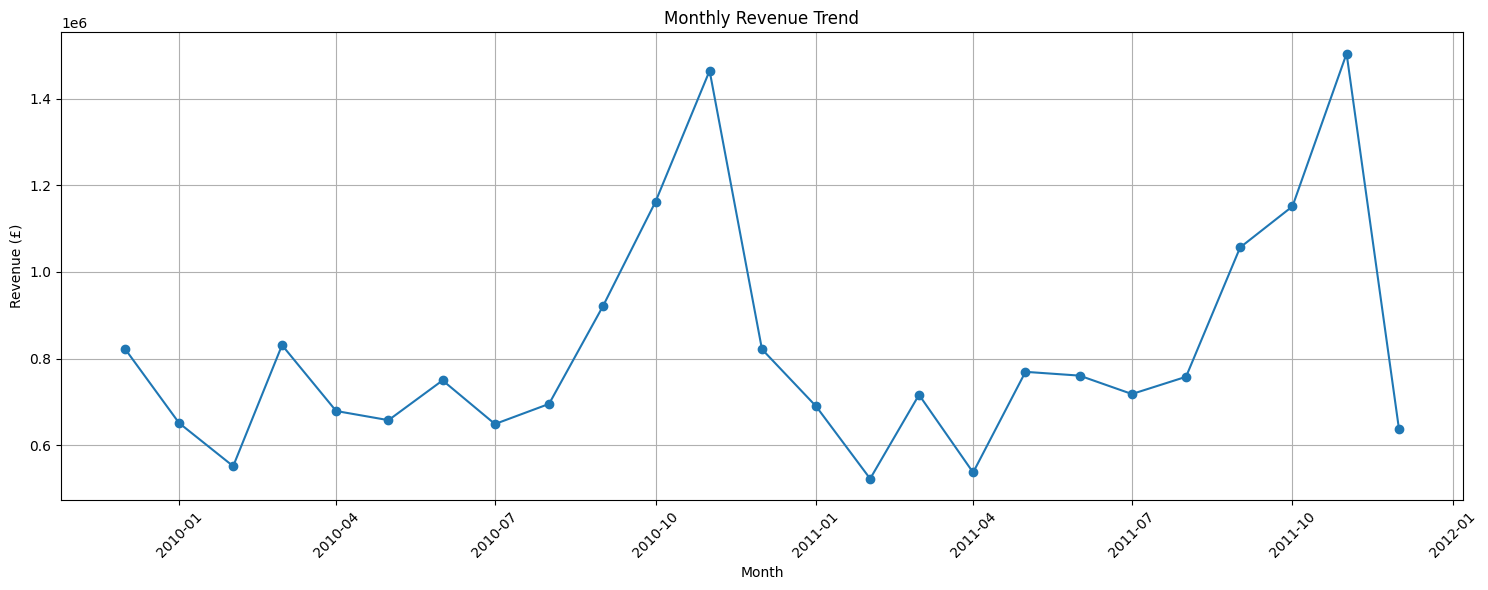

In [40]:

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

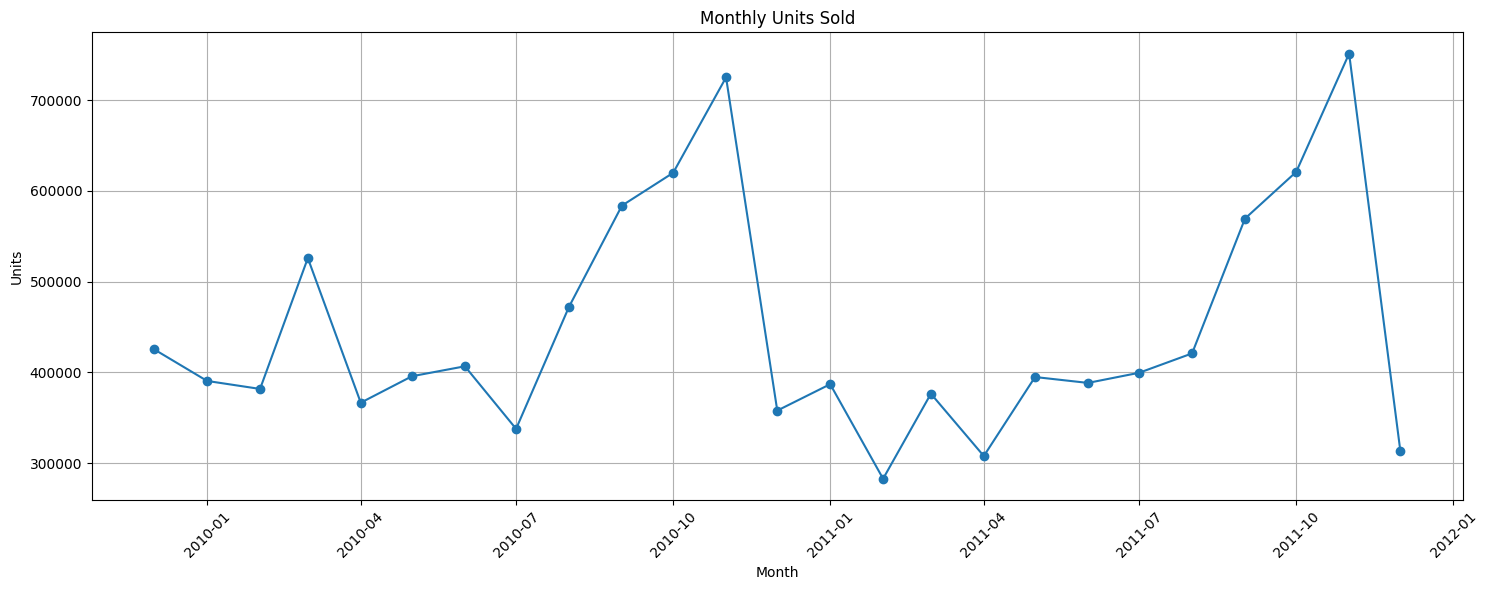

In [41]:

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Units"],
    marker="o"
)

plt.title(
    "Monthly Units Sold"
)

plt.xlabel("Month")

plt.ylabel("Units")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

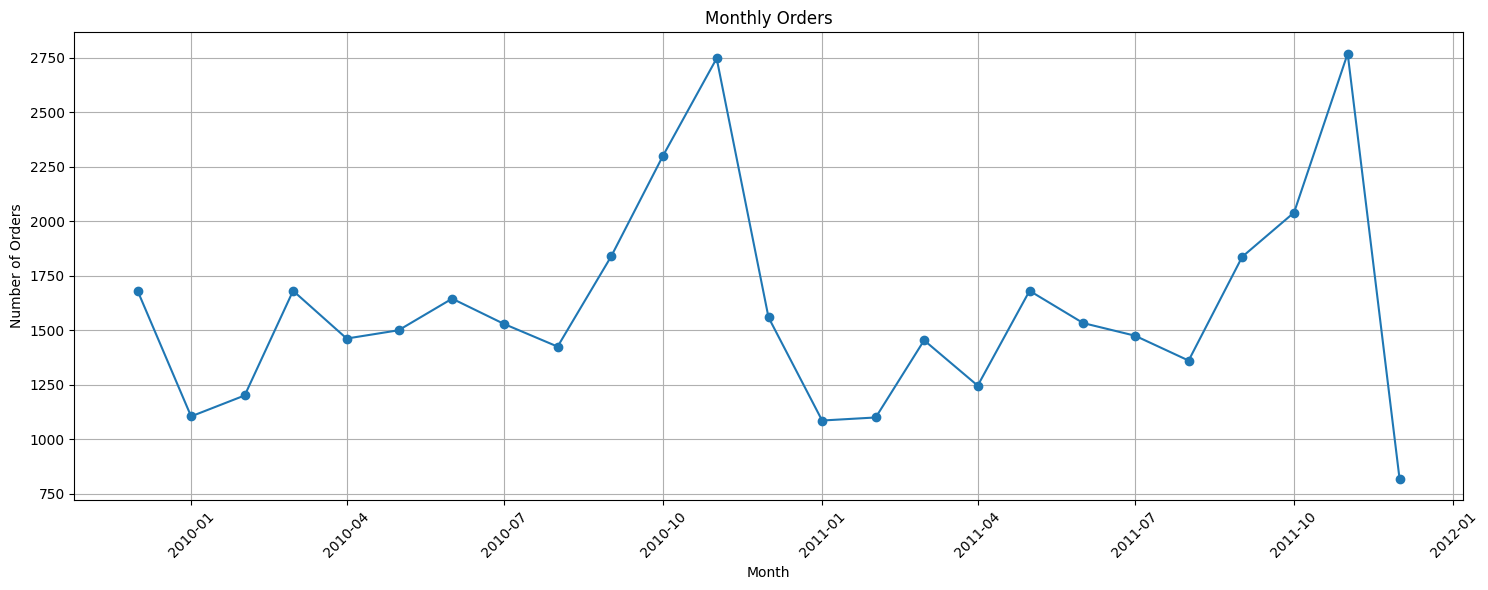

In [42]:

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Orders"],
    marker="o"
)

plt.title(
    "Monthly Orders"
)

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [43]:

country_sales = (
    df_clean
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

display(
    country_sales.head(15)
)

,Revenue,Orders,Customers
Country,,,
United Kingdom,1.741020e+07,36535,5350
EIRE,6.587673e+05,626,5
Netherlands,5.540381e+05,228,22
Germany,4.250197e+05,789,107
France,3.504561e+05,622,95
Australia,1.692835e+05,95,15
Spain,1.083325e+05,154,41
Switzerland,1.006856e+05,93,22
Sweden,9.186982e+04,105,19


In [44]:

product_sales = (
    df_clean
    .groupby(
        ["StockCode", "Description"]
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Invoice", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

display(
    product_sales.head(20)
)

,,Revenue,Units,Orders
StockCode,Description,,,
M,Manual,339226.24,9629,784
22423,REGENCY CAKESTAND 3 TIER,330590.32,26478,3918
DOT,DOTCOM POSTAGE,309854.11,1415,1415
85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,94142,5356
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
47566,PARTY BUNTING,148318.28,28200,2674
85099B,JUMBO BAG RED RETROSPOT,145961.83,77280,3245
84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807
POST,POSTAGE,125682.42,5363,1851


In [45]:
df_clean.to_csv(
    "clean_retail_sales.csv",
    index=False
)

monthly_sales.to_csv(
    "monthly_sales.csv",
    index=False
)

print("Clean datasets saved successfully!")

Clean datasets saved successfully!


## **TASK 2 – TIME SERIES ANALYSIS & DECOMPOSITION**

### **Import Time-Series Libraries**

In [46]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

print("Time Series libraries imported successfully!")

Time Series libraries imported successfully!


### **Prepare Monthly Sales Time Series**

In [47]:

monthly_ts = monthly_sales.copy()

monthly_ts["InvoiceDate"] = pd.to_datetime(
    monthly_ts["InvoiceDate"]
)

monthly_ts = monthly_ts.sort_values(
    "InvoiceDate"
)

monthly_ts = monthly_ts.set_index(
    "InvoiceDate"
)

sales_series = monthly_ts["Revenue"]

print("Monthly Sales Time Series:")
display(sales_series)

Monthly Sales Time Series:


,Revenue
InvoiceDate,
2009-12-01,822483.950
2010-01-01,651155.112
2010-02-01,551504.726
2010-03-01,830915.261
2010-04-01,678875.252
2010-05-01,657705.500
2010-06-01,749537.310
2010-07-01,648810.270
2010-08-01,695251.910


### **Check Time-Series Frequency**

In [48]:
print("Start Date:", sales_series.index.min())

print("End Date:", sales_series.index.max())

print("Number of Months:", len(sales_series))

print("Frequency:", sales_series.index.freq)

Start Date: 2009-12-01 00:00:00
End Date: 2011-12-01 00:00:00
Number of Months: 25
Frequency: None


### **Check Missing Months**

In [49]:

complete_months = pd.date_range(
    start=sales_series.index.min(),
    end=sales_series.index.max(),
    freq="MS"
)

missing_months = complete_months.difference(
    sales_series.index
)

print("Number of missing months:", len(missing_months))

if len(missing_months) > 0:
    print("\nMissing Months:")
    print(missing_months)
else:
    print("No missing months found.")

Number of missing months: 0
No missing months found.


### **Plot Overall Monthly Sales Trend**

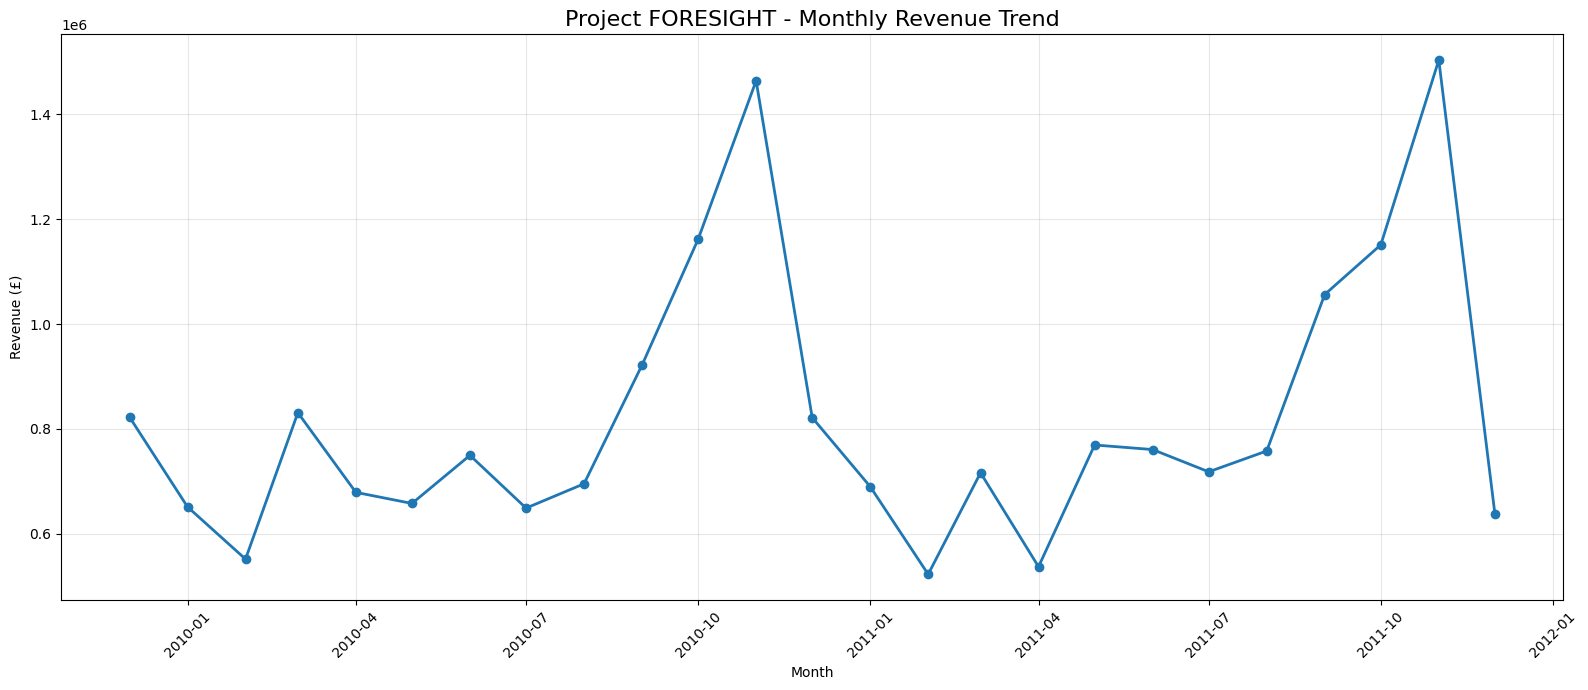

In [50]:
plt.figure(figsize=(16, 7))

plt.plot(
    sales_series.index,
    sales_series.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Project FORESIGHT - Monthly Revenue Trend",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

### **Calculate Rolling Mean**

In [51]:

rolling_3 = sales_series.rolling(
    window=3
).mean()

rolling_6 = sales_series.rolling(
    window=6
).mean()

rolling_12 = sales_series.rolling(
    window=12
).mean()

### **Plot Rolling Averages**

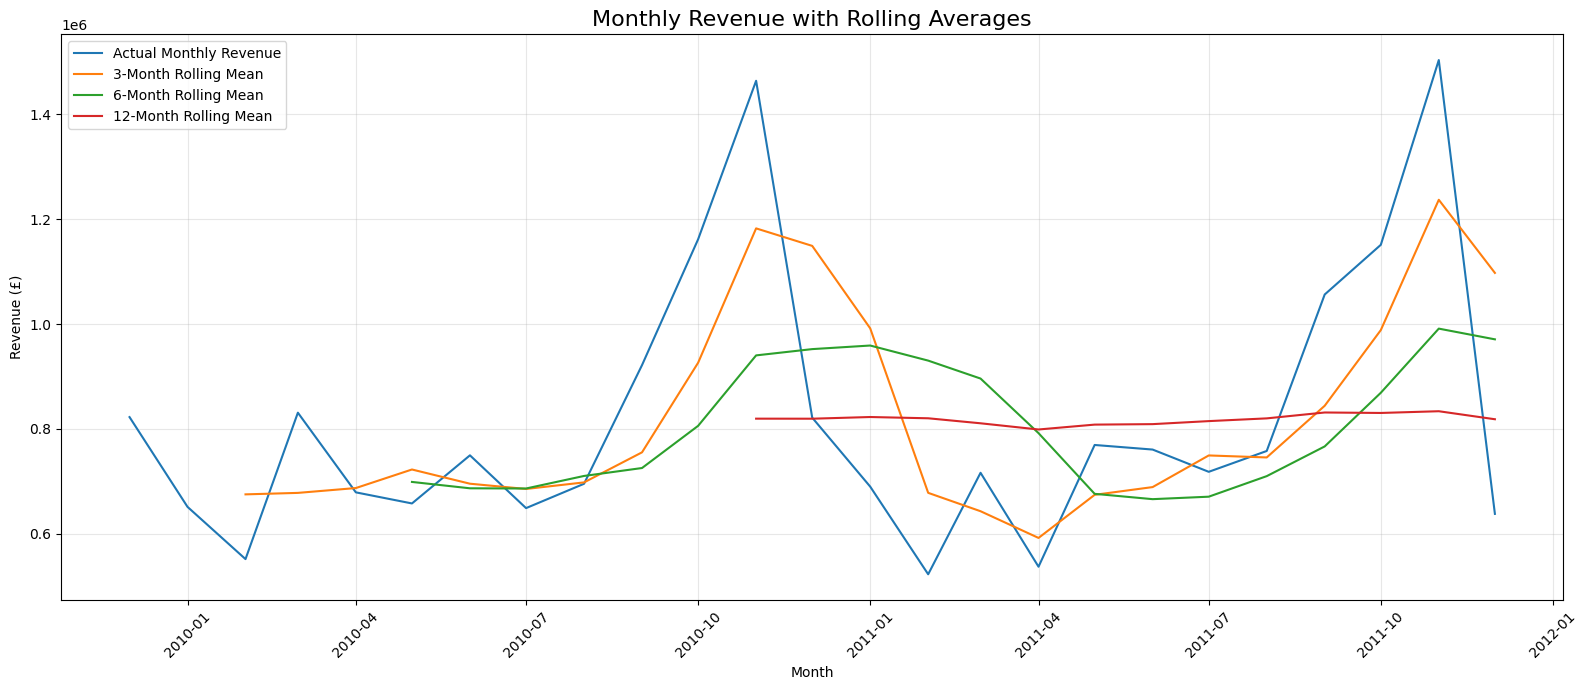

In [52]:

plt.figure(figsize=(16, 7))

plt.plot(
    sales_series.index,
    sales_series,
    label="Actual Monthly Revenue"
)

plt.plot(
    sales_series.index,
    rolling_3,
    label="3-Month Rolling Mean"
)

plt.plot(
    sales_series.index,
    rolling_6,
    label="6-Month Rolling Mean"
)

plt.plot(
    sales_series.index,
    rolling_12,
    label="12-Month Rolling Mean"
)

plt.title(
    "Monthly Revenue with Rolling Averages",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### **Analyze Monthly Seasonality**

In [53]:

seasonality_df = monthly_ts.copy()

seasonality_df["Month"] = (
    seasonality_df.index.month
)

seasonality_df["Month_Name"] = (
    seasonality_df.index.month_name()
)

monthly_seasonality = (
    seasonality_df
    .groupby(
        ["Month", "Month_Name"]
    )["Revenue"]
    .mean()
    .reset_index()
)

monthly_seasonality = (
    monthly_seasonality
    .sort_values("Month")
)

display(monthly_seasonality)

,Month,Month_Name,Revenue
0,1,January,6.704834e+05
1,2,February,5.370251e+05
2,3,March,7.735653e+05
3,4,April,6.079219e+05
4,5,May,7.135011e+05
5,6,June,7.550422e+05
6,7,July,6.834432e+05
7,8,August,7.265466e+05
8,9,September,9.890661e+05
9,10,October,1.156583e+06


### **Plot Monthly Seasonality**

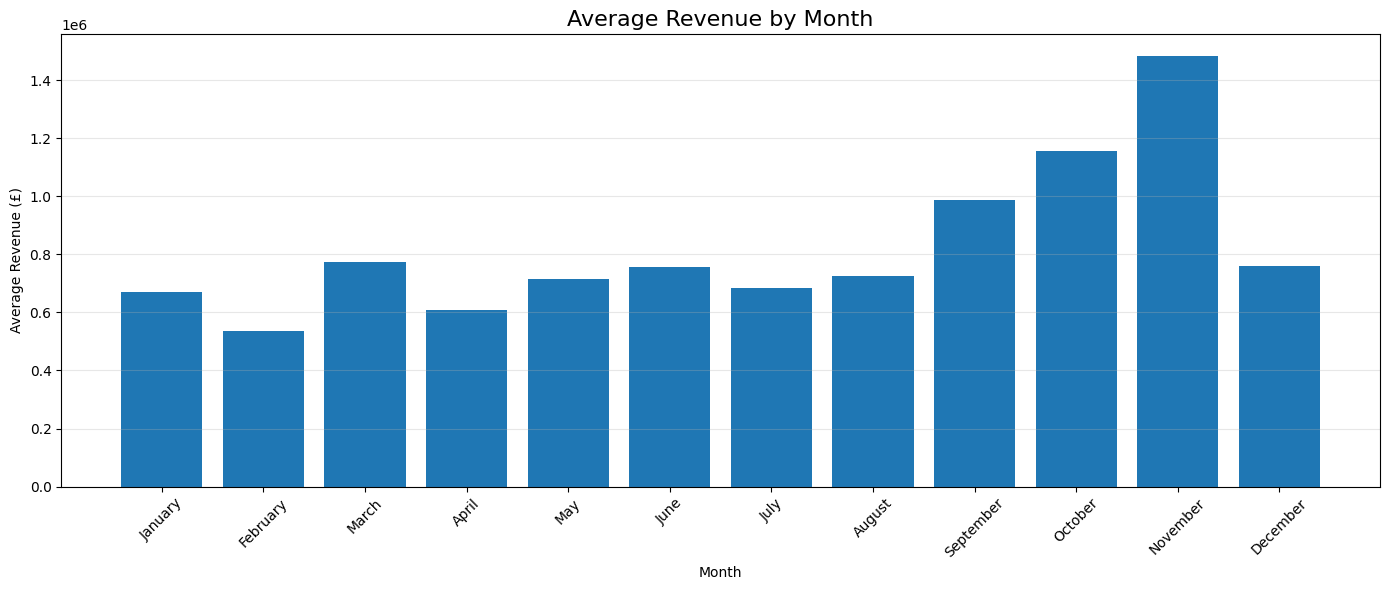

In [54]:

plt.figure(figsize=(14, 6))

plt.bar(
    monthly_seasonality["Month_Name"],
    monthly_seasonality["Revenue"]
)

plt.title(
    "Average Revenue by Month",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Average Revenue (£)")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### **Identify Highest and Lowest Revenue Months**

In [55]:
highest_month = (
    monthly_seasonality
    .loc[
        monthly_seasonality["Revenue"].idxmax()
    ]
)

lowest_month = (
    monthly_seasonality
    .loc[
        monthly_seasonality["Revenue"].idxmin()
    ]
)

print(
    "Highest Average Revenue Month:",
    highest_month["Month_Name"]
)

print(
    "Average Revenue:",
    round(
        highest_month["Revenue"],
        2
    )
)

print()

print(
    "Lowest Average Revenue Month:",
    lowest_month["Month_Name"]
)

print(
    "Average Revenue:",
    round(
        lowest_month["Revenue"],
        2
    )
)

Highest Average Revenue Month: November
Average Revenue: 1484079.96

Lowest Average Revenue Month: February
Average Revenue: 537025.14


In [56]:
decomposition = seasonal_decompose(
    sales_series,
    model="additive",
    period=12
)

print("Time-series decomposition completed.")

Time-series decomposition completed.


### **Extract Components**

In [57]:
trend = decomposition.trend

seasonal = decomposition.seasonal

residual = decomposition.resid

observed = decomposition.observed

print("Observed:")
display(observed.head())

print("\nTrend:")
display(trend.head())

print("\nSeasonal:")
display(seasonal.head())

print("\nResidual:")
display(residual.head())

Observed:


,Revenue
InvoiceDate,
2009-12-01,822483.950
2010-01-01,651155.112
2010-02-01,551504.726
2010-03-01,830915.261
2010-04-01,678875.252



Trend:


,trend
InvoiceDate,
2009-12-01,NaN
2010-01-01,NaN
2010-02-01,NaN
2010-03-01,NaN
2010-04-01,NaN



Seasonal:


,seasonal
InvoiceDate,
2009-12-01,22196.722944
2010-01-01,-112789.211681
2010-02-01,-285549.233389
2010-03-01,-100101.519681
2010-04-01,-284519.109972



Residual:


,resid
InvoiceDate,
2009-12-01,NaN
2010-01-01,NaN
2010-02-01,NaN
2010-03-01,NaN
2010-04-01,NaN


### **Plot Decomposition**

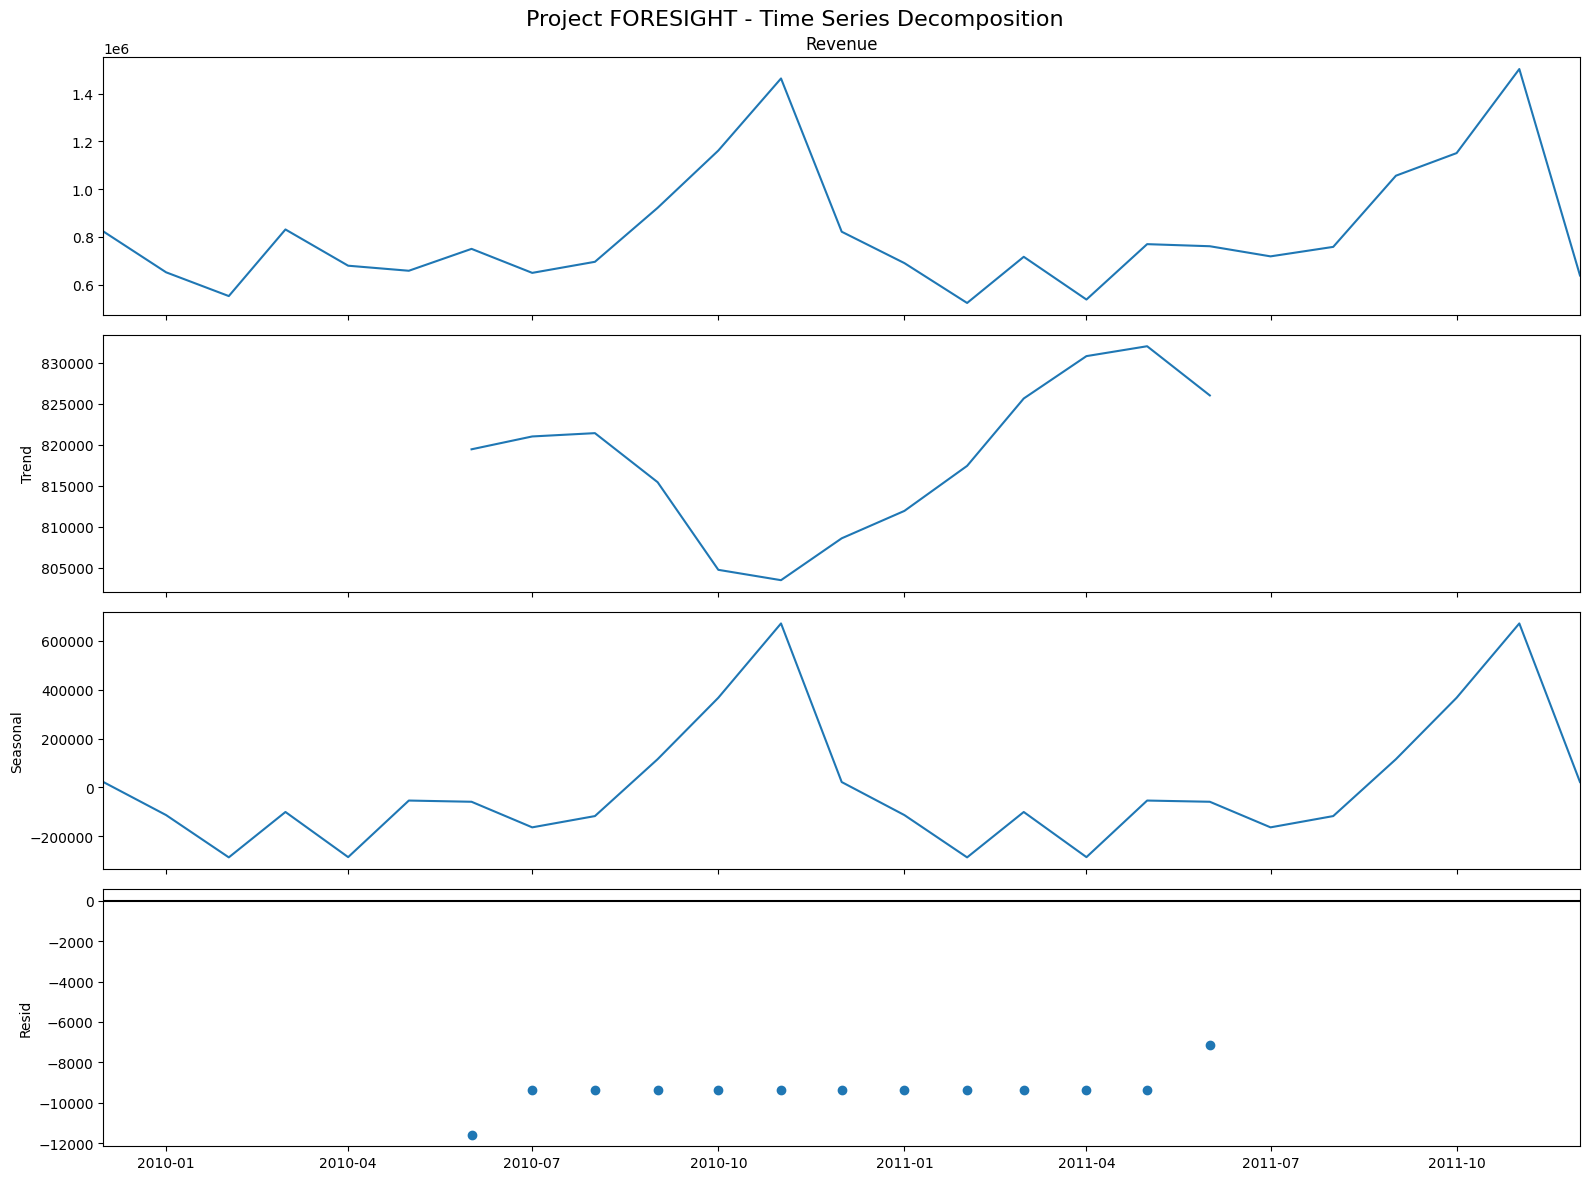

In [58]:

fig = decomposition.plot()

fig.set_size_inches(
    16,
    12
)

plt.suptitle(
    "Project FORESIGHT - Time Series Decomposition",
    fontsize=16
)

plt.tight_layout()

plt.show()


### **Analyze Trend**

In [59]:

trend_clean = trend.dropna()

trend_start = trend_clean.iloc[0]

trend_end = trend_clean.iloc[-1]

trend_change = (
    (trend_end - trend_start)
    / trend_start
) * 100

print(
    f"Starting Trend Revenue: £{trend_start:,.2f}"
)

print(
    f"Ending Trend Revenue: £{trend_end:,.2f}"
)

print(
    f"Trend Change: {trend_change:.2f}%"
)

Starting Trend Revenue: £819,468.00
Ending Trend Revenue: £826,041.52
Trend Change: 0.80%


### **Analyze Seasonal Component**

In [60]:

seasonal_summary = pd.DataFrame({
    "Month": seasonal.index.month,
    "Month_Name": seasonal.index.month_name(),
    "Seasonal_Component": seasonal.values
})

seasonal_summary = (
    seasonal_summary
    .groupby(
        ["Month", "Month_Name"]
    )["Seasonal_Component"]
    .mean()
    .reset_index()
)

seasonal_summary = (
    seasonal_summary
    .sort_values("Month")
)

display(seasonal_summary)

,Month,Month_Name,Seasonal_Component
0,1,January,-112789.211681
1,2,February,-285549.233389
2,3,March,-100101.519681
3,4,April,-284519.109972
4,5,May,-53396.622139
5,6,June,-58361.363722
6,7,July,-162874.213639
7,8,August,-116836.629139
8,9,September,115594.250486
9,10,October,366491.427903


### **Plot Seasonal Component**

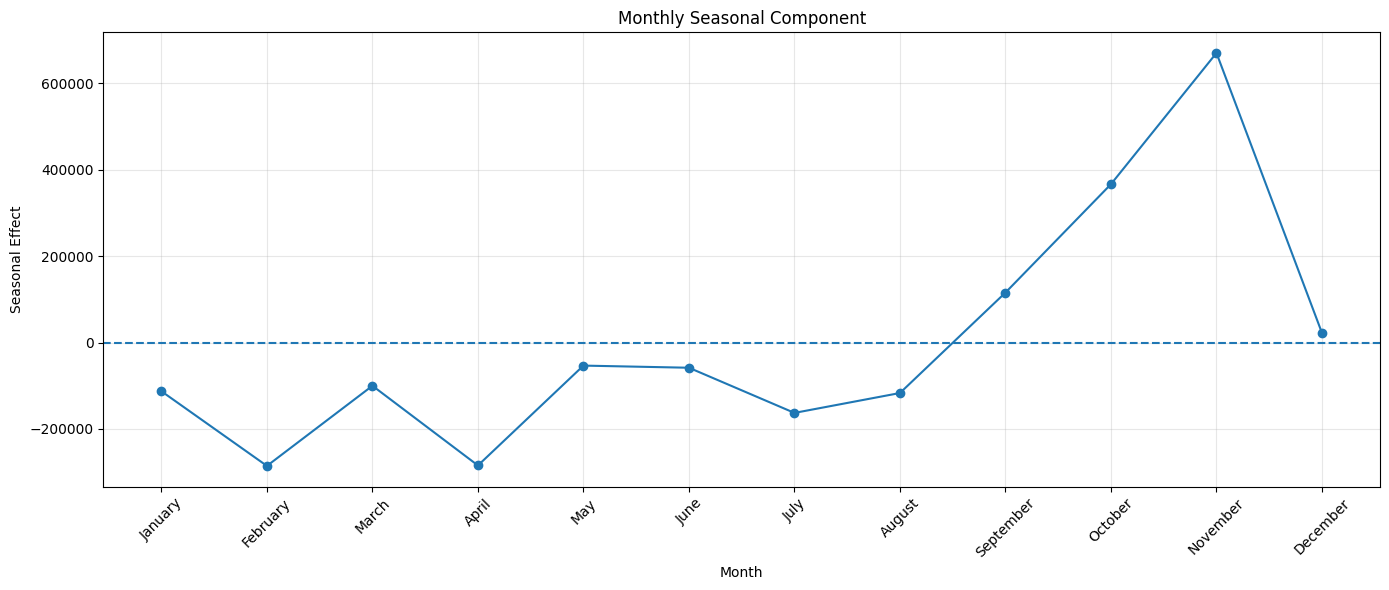

In [61]:

plt.figure(figsize=(14, 6))

plt.plot(
    seasonal_summary["Month_Name"],
    seasonal_summary["Seasonal_Component"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Monthly Seasonal Component"
)

plt.xlabel("Month")

plt.ylabel("Seasonal Effect")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

### **Augmented Dickey-Fuller Test**

In [62]:

adf_result = adfuller(
    sales_series.dropna()
)

adf_statistic = adf_result[0]

p_value = adf_result[1]

critical_values = adf_result[4]

print(
    "ADF Statistic:",
    adf_statistic
)

print(
    "p-value:",
    p_value
)

print("\nCritical Values:")

for key, value in critical_values.items():
    print(
        f"{key}: {value}"
    )

ADF Statistic: -3.664275856289745
p-value: 0.004644647712874594

Critical Values:
1%: -3.9644434814814815
5%: -3.0849081481481484
10%: -2.6818144444444445


### **Interpret ADF Test**

In [63]:

alpha = 0.05

if p_value < alpha:

    print(
        "Result: The time series is stationary."
    )

    print(
        "We reject the null hypothesis."
    )

else:

    print(
        "Result: The time series is non-stationary."
    )

    print(
        "We fail to reject the null hypothesis."
    )

Result: The time series is stationary.
We reject the null hypothesis.


### **First Differencing**

In [64]:
sales_diff = sales_series.diff()

sales_diff = sales_diff.dropna()

display(
    sales_diff.head()
)

,Revenue
InvoiceDate,
2010-01-01,-171328.838
2010-02-01,-99650.386
2010-03-01,279410.535
2010-04-01,-152040.009
2010-05-01,-21169.752


### **Plot Differenced Series**

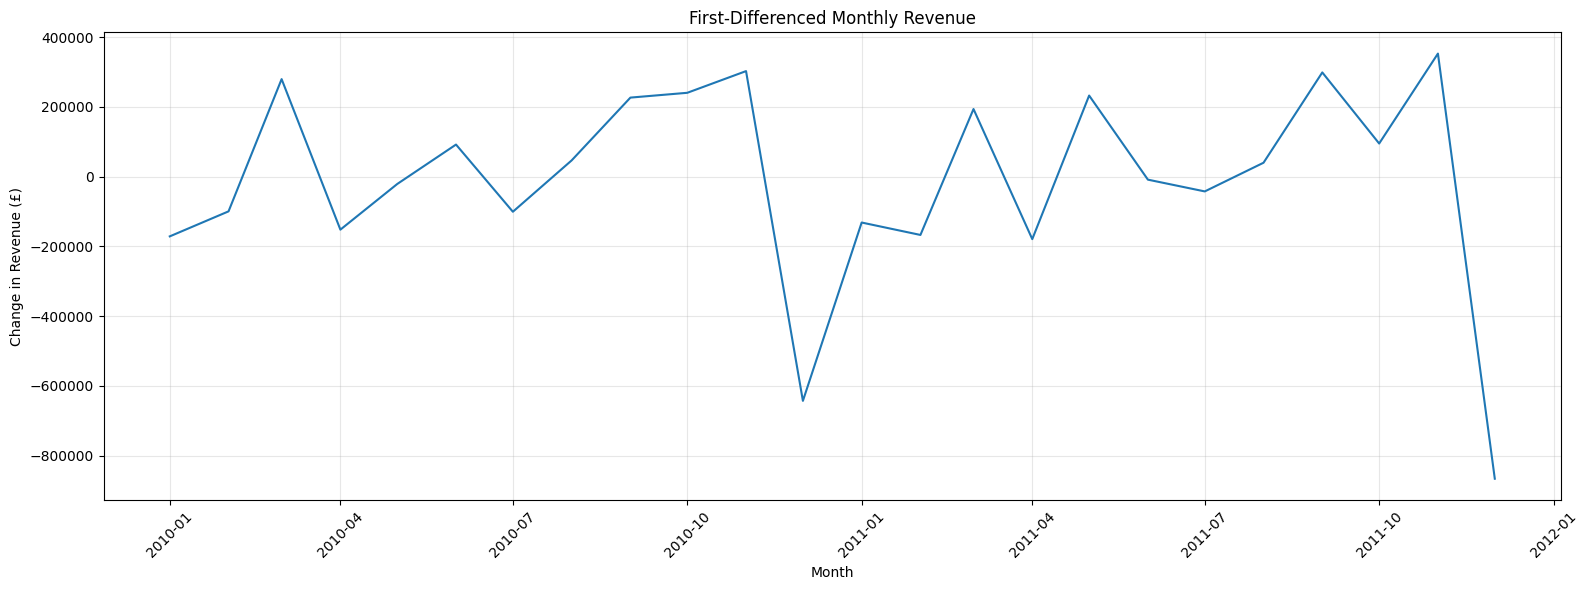

In [65]:
plt.figure(figsize=(16, 6))

plt.plot(
    sales_diff.index,
    sales_diff.values
)

plt.title(
    "First-Differenced Monthly Revenue"
)

plt.xlabel("Month")

plt.ylabel("Change in Revenue (£)")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

### **Re-run ADF Test**

In [66]:
adf_diff_result = adfuller(
    sales_diff
)

adf_diff_statistic = (
    adf_diff_result[0]
)

adf_diff_pvalue = (
    adf_diff_result[1]
)

print(
    "ADF Statistic after differencing:",
    adf_diff_statistic
)

print(
    "p-value after differencing:",
    adf_diff_pvalue
)

ADF Statistic after differencing: -2.3609066378041534
p-value after differencing: 0.15307549023989653


### **Interpret Differenced ADF Test**

In [67]:


if adf_diff_pvalue < 0.05:

    print(
        "The differenced series is stationary."
    )

    print(
        "Suitable for ARIMA/SARIMA modeling."
    )

else:

    print(
        "The differenced series is still non-stationary."
    )

    print(
        "Additional differencing may be required."
    )

The differenced series is still non-stationary.
Additional differencing may be required.


### **Calculate Month-over-Month Growth**

In [68]:
monthly_growth = (
    sales_series
    .pct_change() * 100
)

growth_df = pd.DataFrame({
    "Revenue": sales_series,
    "MoM_Growth_%": monthly_growth
})

display(
    growth_df.tail(15)
)

,Revenue,MoM_Growth_%
InvoiceDate,,
2010-10-01,1161902.220,26.061193
2010-11-01,1464293.142,26.025505
2010-12-01,821452.730,-43.901074
2011-01-01,689811.610,-16.025404
2011-02-01,522545.560,-24.248077
2011-03-01,716215.260,37.062740
2011-04-01,536968.491,-25.026941
2011-05-01,769296.610,43.266620
2011-06-01,760547.010,-1.137351


### **Plot Revenue Growth**

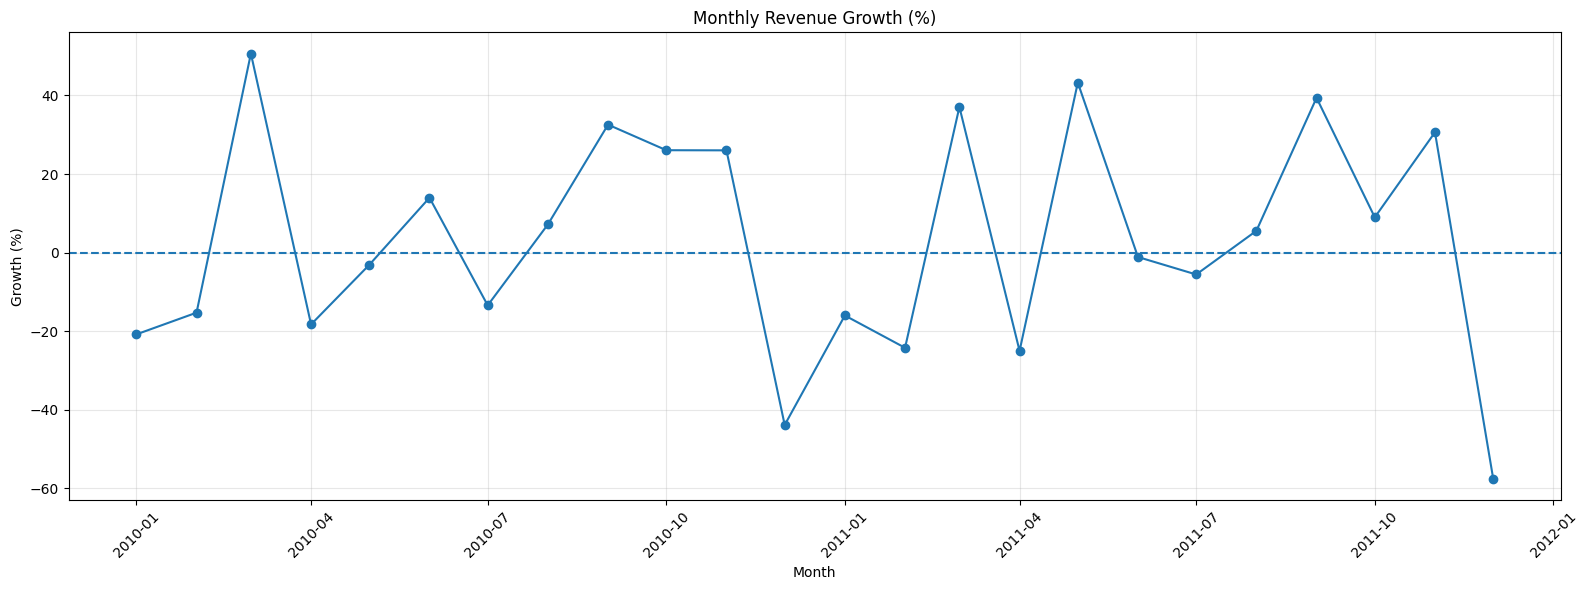

In [69]:
plt.figure(figsize=(16, 6))

plt.plot(
    growth_df.index,
    growth_df["MoM_Growth_%"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Monthly Revenue Growth (%)"
)

plt.xlabel("Month")

plt.ylabel("Growth (%)")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()



### **Identify Strongest Growth Month**

In [70]:
# ============================================================
# STEP 25: STRONGEST MONTHLY GROWTH
# ============================================================

growth_valid = growth_df.dropna(
    subset=["MoM_Growth_%"]
)

strongest_growth = growth_valid.loc[
    growth_valid["MoM_Growth_%"].idxmax()
]

largest_decline = growth_valid.loc[
    growth_valid["MoM_Growth_%"].idxmin()
]

print(
    "Strongest MoM Growth:"
)

print(
    strongest_growth.name.strftime("%B %Y")
)

print(
    f"{strongest_growth['MoM_Growth_%']:.2f}%"
)

print()

print(
    "Largest MoM Decline:"
)

print(
    largest_decline.name.strftime("%B %Y")
)

print(
    f"{largest_decline['MoM_Growth_%']:.2f}%"
)

Strongest MoM Growth:
March 2010
50.66%

Largest MoM Decline:
December 2011
-57.59%


### **Task 2 Business Interpretation**

In [71]:

print("=" * 70)
print("TASK 2 – TIME SERIES ANALYSIS SUMMARY")
print("=" * 70)

print(
    f"Time Period: "
    f"{sales_series.index.min().strftime('%B %Y')} "
    f"to "
    f"{sales_series.index.max().strftime('%B %Y')}"
)

print(
    f"Number of Monthly Observations: "
    f"{len(sales_series)}"
)

print(
    f"Average Monthly Revenue: "
    f"£{sales_series.mean():,.2f}"
)

print(
    f"Maximum Monthly Revenue: "
    f"£{sales_series.max():,.2f}"
)

print(
    f"Minimum Monthly Revenue: "
    f"£{sales_series.min():,.2f}"
)

print(
    f"ADF p-value: "
    f"{p_value:.4f}"
)

print(
    f"ADF p-value after differencing: "
    f"{adf_diff_pvalue:.4f}"
)

print("=" * 70)

TASK 2 – TIME SERIES ANALYSIS SUMMARY
Time Period: December 2009 to December 2011
Number of Monthly Observations: 25
Average Monthly Revenue: £819,050.42
Maximum Monthly Revenue: £1,503,866.78
Minimum Monthly Revenue: £522,545.56
ADF p-value: 0.0046
ADF p-value after differencing: 0.1531


# **TASK 3 — Build Baseline Model**

### **Import Required Libraries**

In [72]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")

print("Baseline forecasting libraries imported successfully!")

Baseline forecasting libraries imported successfully!


### **Prepare Monthly Revenue Data**

In [73]:

baseline_df = monthly_sales.copy()

baseline_df["InvoiceDate"] = pd.to_datetime(
    baseline_df["InvoiceDate"]
)

baseline_df = baseline_df.sort_values(
    "InvoiceDate"
)

baseline_df = baseline_df.set_index(
    "InvoiceDate"
)

baseline_series = baseline_df["Revenue"]

print("Monthly observations:", len(baseline_series))

print(
    "Start:",
    baseline_series.index.min()
)

print(
    "End:",
    baseline_series.index.max()
)

display(baseline_series)

Monthly observations: 25
Start: 2009-12-01 00:00:00
End: 2011-12-01 00:00:00


,Revenue
InvoiceDate,
2009-12-01,822483.950
2010-01-01,651155.112
2010-02-01,551504.726
2010-03-01,830915.261
2010-04-01,678875.252
2010-05-01,657705.500
2010-06-01,749537.310
2010-07-01,648810.270
2010-08-01,695251.910


### **Check Monthly Frequency**

In [74]:
print(
    "Missing values:",
    baseline_series.isna().sum()
)

print(
    "Number of observations:",
    len(baseline_series)
)

Missing values: 0
Number of observations: 25


### **Train-Test Split**

In [75]:

test_size = 6

train = baseline_series.iloc[
    :-test_size
]

test = baseline_series.iloc[
    -test_size:
]

print("Training observations:", len(train))

print("Testing observations:", len(test))

print(
    "\nTraining period:",
    train.index.min(),
    "to",
    train.index.max()
)

print(
    "Testing period:",
    test.index.min(),
    "to",
    test.index.max()
)


Training observations: 19
Testing observations: 6

Training period: 2009-12-01 00:00:00 to 2011-06-01 00:00:00
Testing period: 2011-07-01 00:00:00 to 2011-12-01 00:00:00


### **Display Train/Test Data**

In [76]:
print("Training Data:")
display(train)

print("\nTesting Data:")
display(test)

Training Data:


,Revenue
InvoiceDate,
2009-12-01,822483.950
2010-01-01,651155.112
2010-02-01,551504.726
2010-03-01,830915.261
2010-04-01,678875.252
2010-05-01,657705.500
2010-06-01,749537.310
2010-07-01,648810.270
2010-08-01,695251.910



Testing Data:


,Revenue
InvoiceDate,
2011-07-01,718076.121
2011-08-01,757841.380
2011-09-01,1056435.192
2011-10-01,1151263.730
2011-11-01,1503866.780
2011-12-01,637808.330


### **Visualize Train/Test Split**

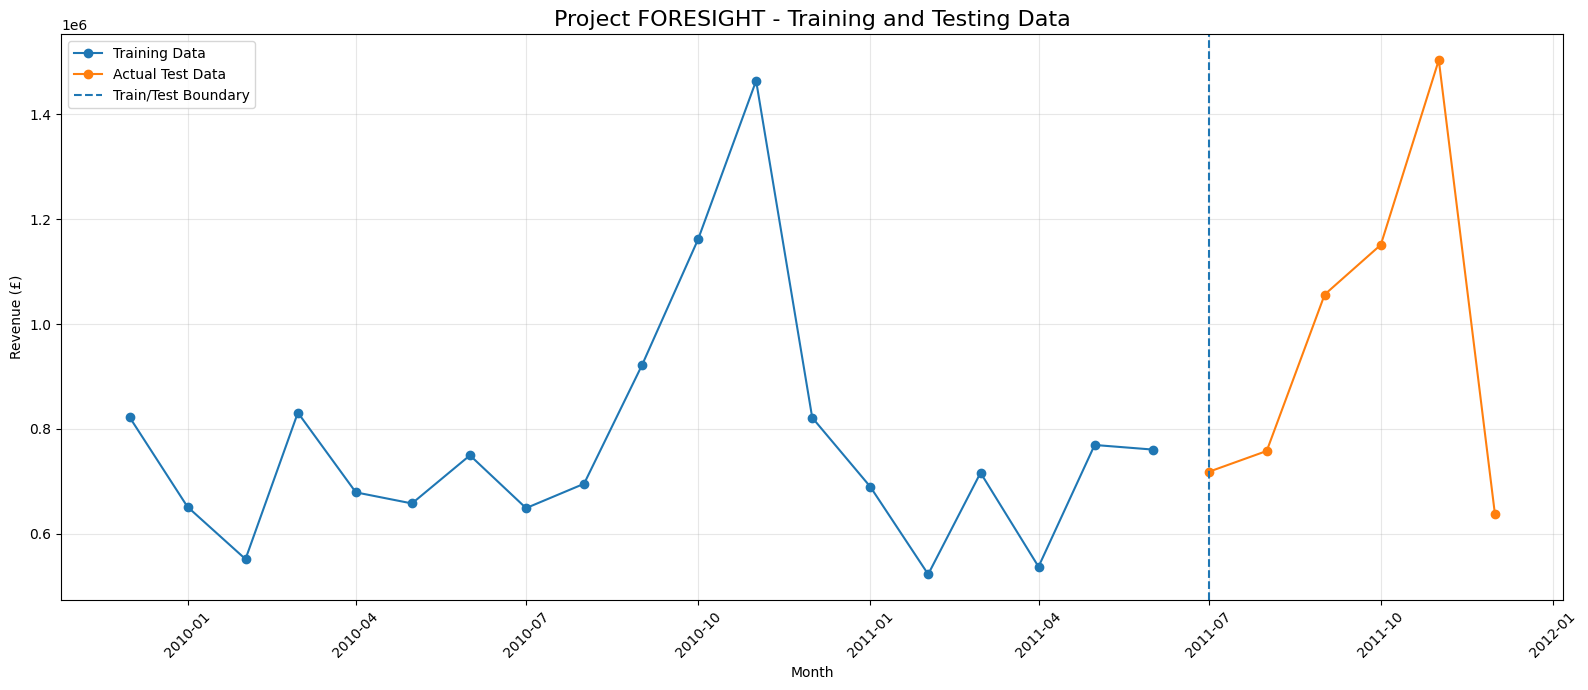

In [77]:

plt.figure(figsize=(16, 7))

plt.plot(
    train.index,
    train.values,
    label="Training Data",
    marker="o"
)

plt.plot(
    test.index,
    test.values,
    label="Actual Test Data",
    marker="o"
)

plt.axvline(
    x=test.index[0],
    linestyle="--",
    label="Train/Test Boundary"
)

plt.title(
    "Project FORESIGHT - Training and Testing Data",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### **Build Naive Forecast**

In [78]:

last_train_value = train.iloc[-1]

naive_forecast = pd.Series(
    last_train_value,
    index=test.index
)

print(
    "Last training revenue:",
    f"£{last_train_value:,.2f}"
)

print("\nNaive Forecast:")

display(naive_forecast)

Last training revenue: £760,547.01

Naive Forecast:


,0
InvoiceDate,
2011-07-01,760547.01
2011-08-01,760547.01
2011-09-01,760547.01
2011-10-01,760547.01
2011-11-01,760547.01
2011-12-01,760547.01


### **Calculate Naive MAE**

In [79]:

naive_mae = mean_absolute_error(
    test,
    naive_forecast
)

print(
    f"Naive MAE: £{naive_mae:,.2f}"
)

Naive MAE: £266,306.65


### **Calculate Naive RMSE**

In [80]:

naive_rmse = np.sqrt(
    mean_squared_error(
        test,
        naive_forecast
    )
)

print(
    f"Naive RMSE: £{naive_rmse:,.2f}"
)

Naive RMSE: £367,334.89


### **Calculate Naive MAPE**

In [81]:

def calculate_mape(actual, predicted):

    actual = np.array(actual)

    predicted = np.array(predicted)

    mask = actual != 0

    return np.mean(
        np.abs(
            (
                actual[mask]
                -
                predicted[mask]
            )
            /
            actual[mask]
        )
    ) * 100


naive_mape = calculate_mape(
    test,
    naive_forecast
)

print(
    f"Naive MAPE: {naive_mape:.2f}%"
)

Naive MAPE: 22.81%


### **Build Seasonal Naive Forecast**

In [82]:

seasonal_period = 12

seasonal_naive_forecast = pd.Series(
    index=test.index,
    dtype=float
)

for i in range(len(test)):

    seasonal_naive_forecast.iloc[i] = (
        train.iloc[
            len(train)
            -
            seasonal_period
            +
            i
        ]
    )

print("Seasonal Naive Forecast:")

display(
    seasonal_naive_forecast
)

Seasonal Naive Forecast:


,0
InvoiceDate,
2011-07-01,648810.270
2011-08-01,695251.910
2011-09-01,921696.991
2011-10-01,1161902.220
2011-11-01,1464293.142
2011-12-01,821452.730


### **Seasonal Naive MAE**

In [83]:

seasonal_naive_mae = mean_absolute_error(
    test,
    seasonal_naive_forecast
)

print(
    f"Seasonal Naive MAE: "
    f"£{seasonal_naive_mae:,.2f}"
)

Seasonal Naive MAE: £83,408.34


### **Seasonal Naive RMSE**

In [84]:
seasonal_naive_rmse = np.sqrt(
    mean_squared_error(
        test,
        seasonal_naive_forecast
    )
)

print(
    f"Seasonal Naive RMSE: "
    f"£{seasonal_naive_rmse:,.2f}"
)

Seasonal Naive RMSE: £101,877.46


In [85]:

seasonal_naive_mape = calculate_mape(
    test,
    seasonal_naive_forecast
)

print(
    f"Seasonal Naive MAPE: "
    f"{seasonal_naive_mape:.2f}%"
)

Seasonal Naive MAPE: 10.50%


### **Create Baseline Comparison Table**

In [86]:

baseline_results = pd.DataFrame({

    "Model": [
        "Naive",
        "Seasonal Naive"
    ],

    "MAE": [
        naive_mae,
        seasonal_naive_mae
    ],

    "RMSE": [
        naive_rmse,
        seasonal_naive_rmse
    ],

    "MAPE": [
        naive_mape,
        seasonal_naive_mape
    ]
})

baseline_results = baseline_results.sort_values(
    "MAPE"
)

display(
    baseline_results
)

,Model,MAE,RMSE,MAPE
1,Seasonal Naive,83408.341667,101877.457945,10.501260
0,Naive,266306.645167,367334.890897,22.814809


### **Format Results**

In [87]:

formatted_results = baseline_results.copy()

formatted_results["MAE"] = (
    formatted_results["MAE"]
    .map(lambda x: f"£{x:,.2f}")
)

formatted_results["RMSE"] = (
    formatted_results["RMSE"]
    .map(lambda x: f"£{x:,.2f}")
)

formatted_results["MAPE"] = (
    formatted_results["MAPE"]
    .map(lambda x: f"{x:.2f}%")
)

display(
    formatted_results
)

,Model,MAE,RMSE,MAPE
1,Seasonal Naive,"£83,408.34","£101,877.46",10.50%
0,Naive,"£266,306.65","£367,334.89",22.81%


### **Plot Naive Forecast**

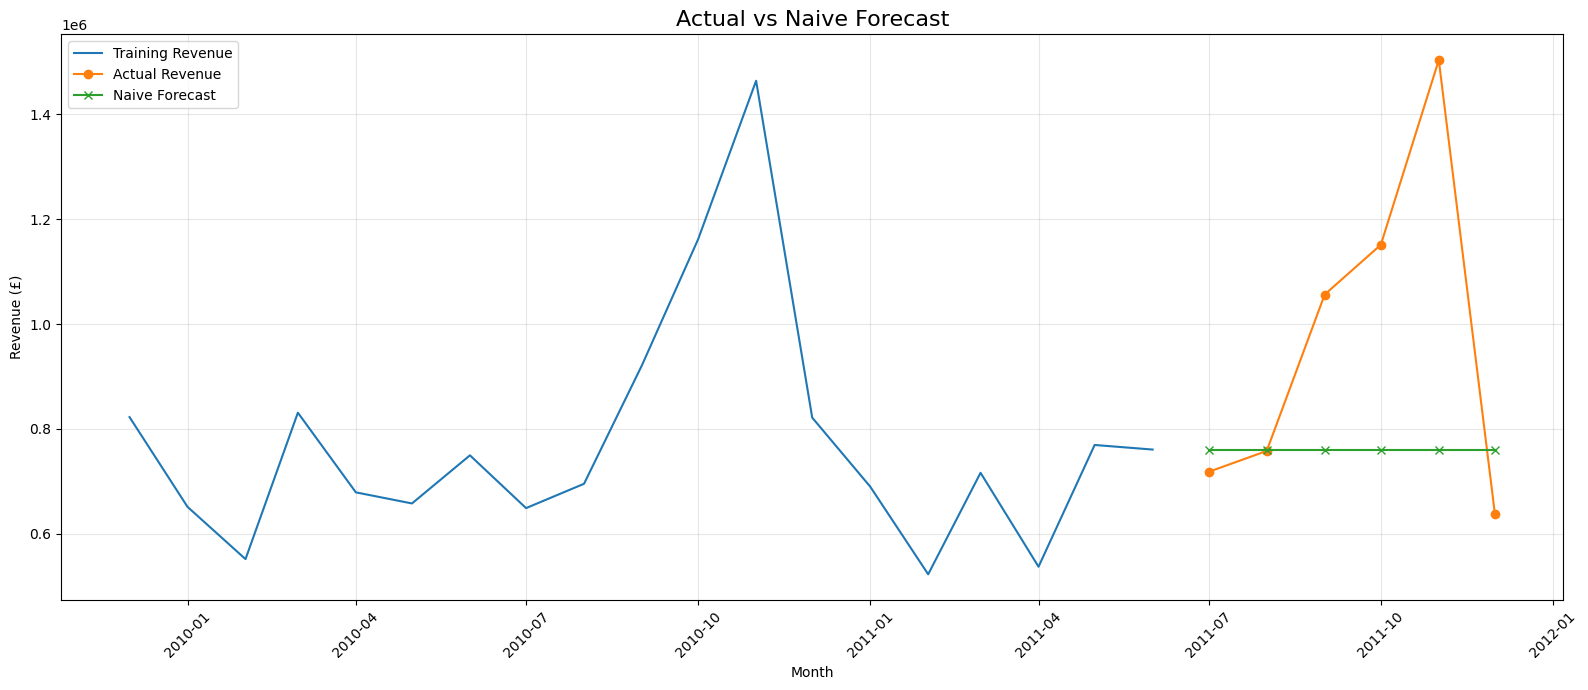

In [88]:
plt.figure(figsize=(16, 7))

plt.plot(
    train.index,
    train.values,
    label="Training Revenue"
)

plt.plot(
    test.index,
    test.values,
    label="Actual Revenue",
    marker="o"
)

plt.plot(
    test.index,
    naive_forecast.values,
    label="Naive Forecast",
    marker="x"
)

plt.title(
    "Actual vs Naive Forecast",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### **Plot Seasonal Naive Forecast**

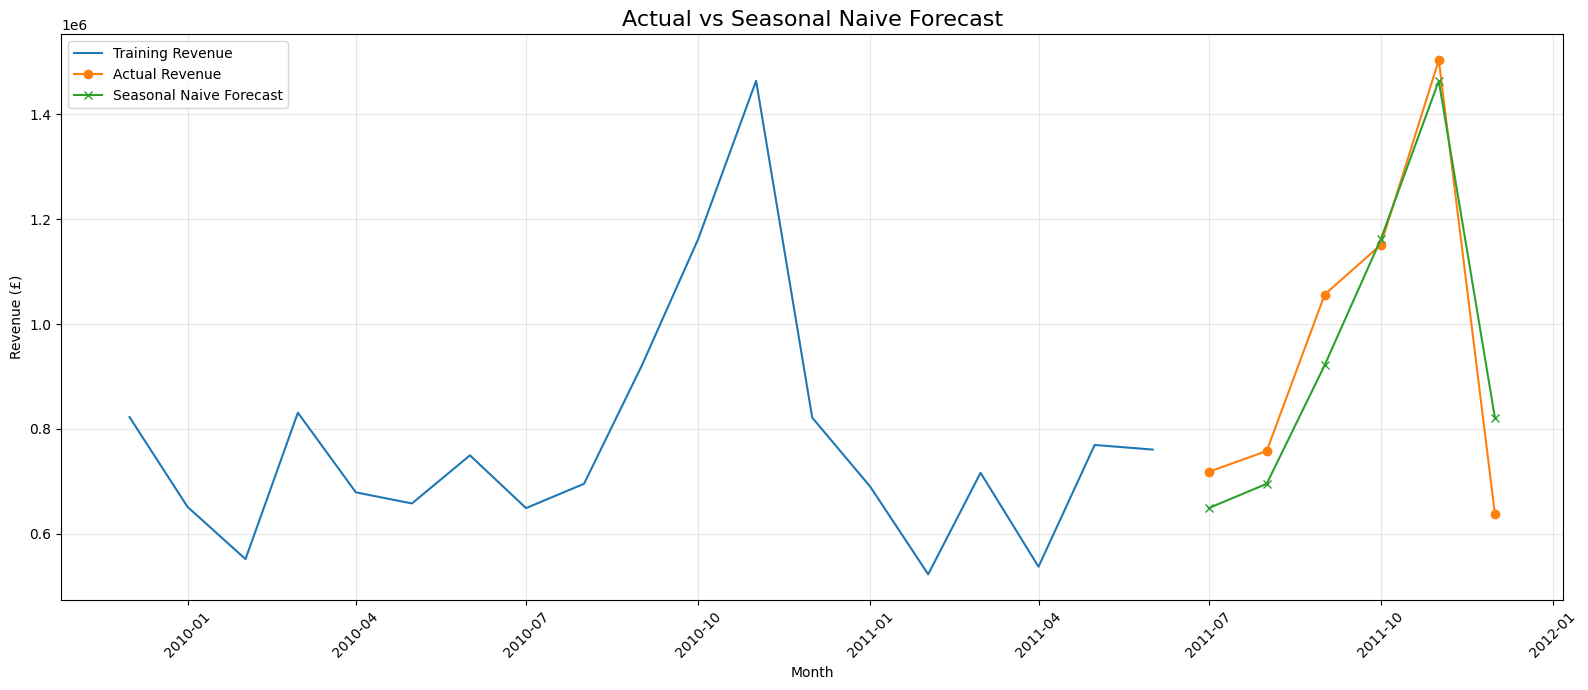

In [89]:

plt.figure(figsize=(16, 7))

plt.plot(
    train.index,
    train.values,
    label="Training Revenue"
)

plt.plot(
    test.index,
    test.values,
    label="Actual Revenue",
    marker="o"
)

plt.plot(
    test.index,
    seasonal_naive_forecast.values,
    label="Seasonal Naive Forecast",
    marker="x"
)

plt.title(
    "Actual vs Seasonal Naive Forecast",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### **Compare Both Forecasts**

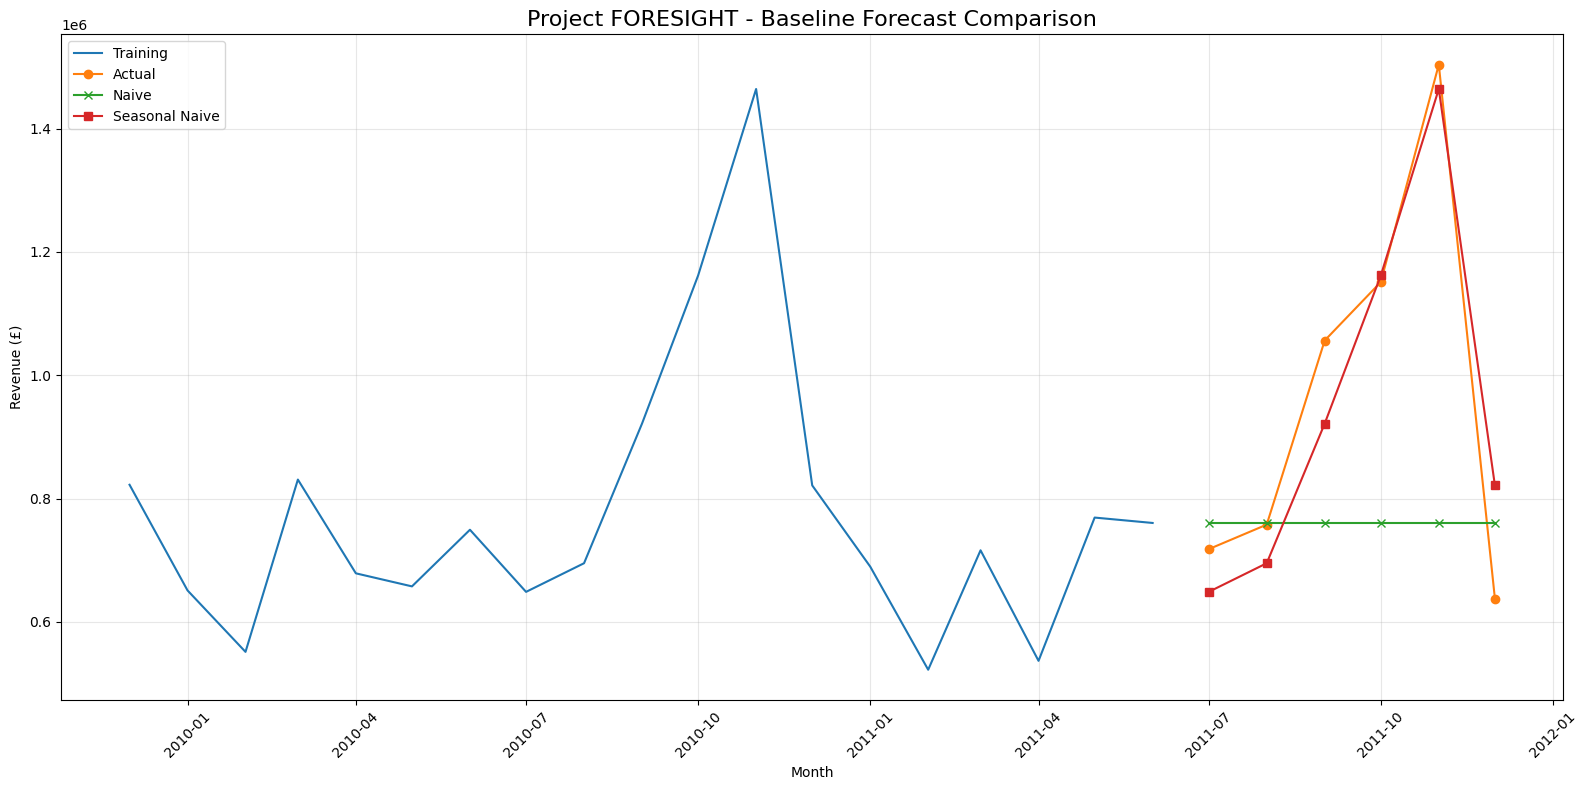

In [90]:

plt.figure(figsize=(16, 8))

plt.plot(
    train.index,
    train.values,
    label="Training"
)

plt.plot(
    test.index,
    test.values,
    label="Actual",
    marker="o"
)

plt.plot(
    test.index,
    naive_forecast.values,
    label="Naive",
    marker="x"
)

plt.plot(
    test.index,
    seasonal_naive_forecast.values,
    label="Seasonal Naive",
    marker="s"
)

plt.title(
    "Project FORESIGHT - Baseline Forecast Comparison",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### **Calculate Improvement**

In [91]:
mape_improvement = (
    (
        naive_mape
        -
        seasonal_naive_mape
    )
    /
    naive_mape
) * 100

print(
    f"Seasonal Naive improvement over Naive: "
    f"{mape_improvement:.2f}%"
)

Seasonal Naive improvement over Naive: 53.97%


### **Select Best Baseline**

In [92]:

best_baseline_row = baseline_results.iloc[0]

best_baseline_model = (
    best_baseline_row["Model"]
)

best_baseline_mape = (
    best_baseline_row["MAPE"]
)

print(
    "Best Baseline Model:",
    best_baseline_model
)

print(
    f"Baseline MAPE: "
    f"{best_baseline_mape:.2f}%"
)

Best Baseline Model: Seasonal Naive
Baseline MAPE: 10.50%


### **Create Baseline Forecast Table**

In [93]:

baseline_forecast_table = pd.DataFrame({

    "Month": test.index,

    "Actual_Revenue": test.values,

    "Naive_Forecast": naive_forecast.values,

    "Seasonal_Naive_Forecast":
        seasonal_naive_forecast.values

})

baseline_forecast_table[
    "Naive_Error"
] = (
    baseline_forecast_table["Actual_Revenue"]
    -
    baseline_forecast_table["Naive_Forecast"]
)

baseline_forecast_table[
    "Seasonal_Naive_Error"
] = (
    baseline_forecast_table["Actual_Revenue"]
    -
    baseline_forecast_table[
        "Seasonal_Naive_Forecast"
    ]
)

display(
    baseline_forecast_table
)

,Month,Actual_Revenue,Naive_Forecast,Seasonal_Naive_Forecast,Naive_Error,Seasonal_Naive_Error
0,2011-07-01,718076.121,760547.01,648810.270,-42470.889,69265.851
1,2011-08-01,757841.380,760547.01,695251.910,-2705.630,62589.470
2,2011-09-01,1056435.192,760547.01,921696.991,295888.182,134738.201
3,2011-10-01,1151263.730,760547.01,1161902.220,390716.720,-10638.490
4,2011-11-01,1503866.780,760547.01,1464293.142,743319.770,39573.638
5,2011-12-01,637808.330,760547.01,821452.730,-122738.680,-183644.400


### **Save Baseline Results**

In [94]:

baseline_results.to_csv(
    "baseline_model_results.csv",
    index=False
)

baseline_forecast_table.to_csv(
    "baseline_forecasts.csv",
    index=False
)

print(
    "Baseline results saved successfully!"
)

Baseline results saved successfully!


### **Final Task 3 Summary**

In [95]:

print("=" * 70)

print(
    "PROJECT FORESIGHT – TASK 3"
)

print(
    "BASELINE FORECASTING RESULTS"
)

print("=" * 70)

print(
    f"Training Months : {len(train)}"
)

print(
    f"Testing Months  : {len(test)}"
)

print()

print(
    f"Naive MAPE      : {naive_mape:.2f}%"
)

print(
    f"Seasonal Naive MAPE : "
    f"{seasonal_naive_mape:.2f}%"
)

print()

print(
    f"Best Baseline   : "
    f"{best_baseline_model}"
)

print(
    f"Best MAPE       : "
    f"{best_baseline_mape:.2f}%"
)

print("=" * 70)

PROJECT FORESIGHT – TASK 3
BASELINE FORECASTING RESULTS
Training Months : 19
Testing Months  : 6

Naive MAPE      : 22.81%
Seasonal Naive MAPE : 10.50%

Best Baseline   : Seasonal Naive
Best MAPE       : 10.50%


### **Automatic Business Interpretation**

In [97]:

if seasonal_naive_mape < naive_mape:

    print(
        "Seasonal Naive performs better than Naive."
    )

    print(
        "This indicates that historical yearly "
        "seasonality contains useful information "
        "for forecasting retail demand."
    )

else:

    print(
        "Naive performs better than Seasonal Naive."
    )

    print(
        "The current validation period does not "
        "show enough benefit from the seasonal benchmark."
    )

Seasonal Naive performs better than Naive.
This indicates that historical yearly seasonality contains useful information for forecasting retail demand.


### **Task 4 — Machine Learning Forecasting**

### **Install Required Libraries**

In [98]:
!pip -q install xgboost lightgbm prophet

### **Import Libraries**

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

### **Prepare Monthly Sales Data**

In [100]:
monthly_ml = monthly_sales.copy()

monthly_ml["InvoiceDate"] = pd.to_datetime(monthly_ml["InvoiceDate"])

monthly_ml = monthly_ml.sort_values("InvoiceDate").reset_index(drop=True)

monthly_ml = monthly_ml[["InvoiceDate", "Revenue"]]

monthly_ml.head()

,InvoiceDate,Revenue
0,2009-12-01,822483.950
1,2010-01-01,651155.112
2,2010-02-01,551504.726
3,2010-03-01,830915.261
4,2010-04-01,678875.252


### **Check Data**

In [101]:
print("Number of monthly observations:", len(monthly_ml))

print("\nDate range:")
print(monthly_ml["InvoiceDate"].min())
print(monthly_ml["InvoiceDate"].max())

print("\nMonthly sales:")
display(monthly_ml)

Number of monthly observations: 25

Date range:
2009-12-01 00:00:00
2011-12-01 00:00:00

Monthly sales:


,InvoiceDate,Revenue
0,2009-12-01,822483.950
1,2010-01-01,651155.112
2,2010-02-01,551504.726
3,2010-03-01,830915.261
4,2010-04-01,678875.252
5,2010-05-01,657705.500
6,2010-06-01,749537.310
7,2010-07-01,648810.270
8,2010-08-01,695251.910
9,2010-09-01,921696.991


### **Create Time-Series Features**

In [102]:
ml_df = monthly_ml.copy()

# Lag features
ml_df["lag_1"] = ml_df["Revenue"].shift(1)
ml_df["lag_2"] = ml_df["Revenue"].shift(2)
ml_df["lag_3"] = ml_df["Revenue"].shift(3)
ml_df["lag_6"] = ml_df["Revenue"].shift(6)

# Rolling features
ml_df["rolling_mean_3"] = (
    ml_df["Revenue"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

ml_df["rolling_mean_6"] = (
    ml_df["Revenue"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

# Calendar features
ml_df["month"] = ml_df["InvoiceDate"].dt.month
ml_df["quarter"] = ml_df["InvoiceDate"].dt.quarter

# Trend index
ml_df["time_index"] = np.arange(len(ml_df))

ml_df.head(10)

,InvoiceDate,Revenue,lag_1,lag_2,lag_3,lag_6,rolling_mean_3,rolling_mean_6,month,quarter,time_index
0,2009-12-01,822483.950,NaN,NaN,NaN,NaN,NaN,NaN,12,4,0
1,2010-01-01,651155.112,822483.950,NaN,NaN,NaN,NaN,NaN,1,1,1
2,2010-02-01,551504.726,651155.112,822483.950,NaN,NaN,NaN,NaN,2,1,2
3,2010-03-01,830915.261,551504.726,651155.112,822483.950,NaN,675047.929333,NaN,3,1,3
4,2010-04-01,678875.252,830915.261,551504.726,651155.112,NaN,677858.366333,NaN,4,2,4
5,2010-05-01,657705.500,678875.252,830915.261,551504.726,NaN,687098.413000,NaN,5,2,5
6,2010-06-01,749537.310,657705.500,678875.252,830915.261,822483.950,722498.671000,698773.300167,6,2,6
7,2010-07-01,648810.270,749537.310,657705.500,678875.252,651155.112,695372.687333,686615.526833,7,3,7
8,2010-08-01,695251.910,648810.270,749537.310,657705.500,551504.726,685351.026667,686224.719833,8,3,8
9,2010-09-01,921696.991,695251.910,648810.270,749537.310,830915.261,697866.496667,710182.583833,9,3,9


### **Remove Rows With Missing Lag Values**

In [103]:
ml_df = ml_df.dropna().reset_index(drop=True)

print("Rows after feature engineering:", len(ml_df))

display(ml_df.head())

Rows after feature engineering: 19


,InvoiceDate,Revenue,lag_1,lag_2,lag_3,lag_6,rolling_mean_3,rolling_mean_6,month,quarter,time_index
0,2010-06-01,749537.310,657705.500,678875.252,830915.261,822483.950,722498.671000,698773.300167,6,2,6
1,2010-07-01,648810.270,749537.310,657705.500,678875.252,651155.112,695372.687333,686615.526833,7,3,7
2,2010-08-01,695251.910,648810.270,749537.310,657705.500,551504.726,685351.026667,686224.719833,8,3,8
3,2010-09-01,921696.991,695251.910,648810.270,749537.310,830915.261,697866.496667,710182.583833,9,3,9
4,2010-10-01,1161902.220,921696.991,695251.910,648810.270,678875.252,755253.057000,725312.872167,10,4,10


### **Train/Test Split**

In [104]:
test_months = 6

test_start = monthly_ml["InvoiceDate"].iloc[-test_months]

train_ml = ml_df[ml_df["InvoiceDate"] < test_start].copy()
test_ml = ml_df[ml_df["InvoiceDate"] >= test_start].copy()

print("Training observations:", len(train_ml))
print("Testing observations:", len(test_ml))

print("\nTest period:")
print(test_ml["InvoiceDate"].min())
print("to")
print(test_ml["InvoiceDate"].max())

Training observations: 13
Testing observations: 6

Test period:
2011-07-01 00:00:00
to
2011-12-01 00:00:00


### **Select Features**

In [105]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "month",
    "quarter",
    "time_index"
]

X_train = train_ml[features]
y_train = train_ml["Revenue"]

X_test = test_ml[features]
y_test = test_ml["Revenue"]

print("Features:")
print(features)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Features:
['lag_1', 'lag_2', 'lag_3', 'lag_6', 'rolling_mean_3', 'rolling_mean_6', 'month', 'quarter', 'time_index']

X_train shape: (13, 9)
X_test shape: (6, 9)


### **Evaluation Function**

In [106]:
def calculate_mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mask = actual != 0

    return np.mean(
        np.abs(
            (actual[mask] - predicted[mask]) /
            actual[mask]
        )
    ) * 100


def evaluate_model(model_name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = calculate_mape(actual, predicted)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

### **Random Forest**

In [107]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_result

{'Model': 'Random Forest',
 'MAE': 201565.88616535204,
 'RMSE': np.float64(267653.87302873906),
 'MAPE': np.float64(21.44790068609667)}

### **Display Random Forest Forecast**

In [108]:
rf_forecast = test_ml[
    ["InvoiceDate", "Revenue"]
].copy()

rf_forecast["Predicted_Revenue"] = rf_pred

display(rf_forecast)

,InvoiceDate,Revenue,Predicted_Revenue
13,2011-07-01,718076.121,6.996470e+05
14,2011-08-01,757841.380,7.209175e+05
15,2011-09-01,1056435.192,8.347060e+05
16,2011-10-01,1151263.730,1.082865e+06
17,2011-11-01,1503866.780,1.048327e+06
18,2011-12-01,637808.330,1.046184e+06


### **Random Forest Plot**

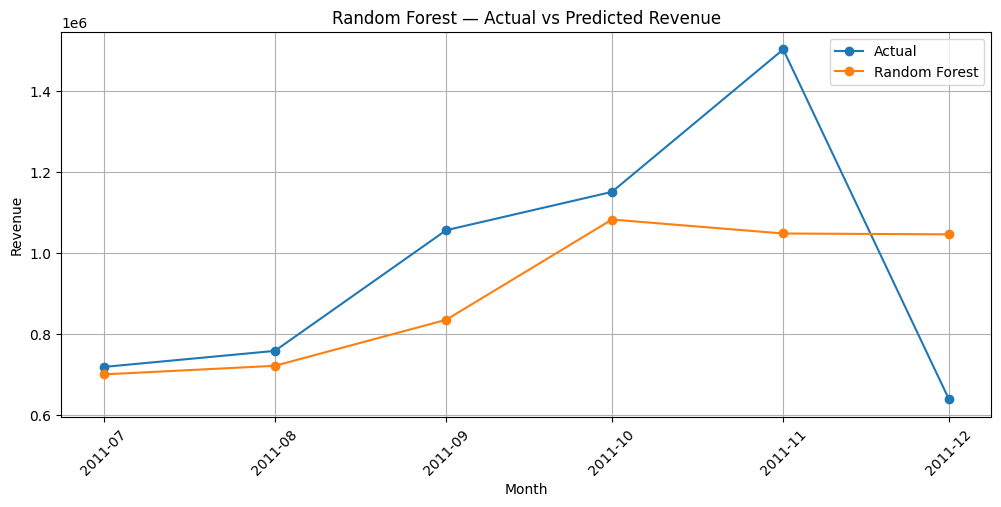

In [109]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_ml["InvoiceDate"],
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    test_ml["InvoiceDate"],
    rf_pred,
    marker="o",
    label="Random Forest"
)

plt.title("Random Forest — Actual vs Predicted Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### **XGBoost Model**

In [110]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_test)

xgb_result = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

xgb_result

{'Model': 'XGBoost',
 'MAE': 184591.07258333336,
 'RMSE': np.float64(247706.99330958715),
 'MAPE': np.float64(18.21914110665186)}

### **XGBoost Forecast**

In [111]:
xgb_forecast = test_ml[
    ["InvoiceDate", "Revenue"]
].copy()

xgb_forecast["Predicted_Revenue"] = xgb_pred

display(xgb_forecast)

,InvoiceDate,Revenue,Predicted_Revenue
13,2011-07-01,718076.121,6.929045e+05
14,2011-08-01,757841.380,6.919804e+05
15,2011-09-01,1056435.192,8.355152e+05
16,2011-10-01,1151263.730,1.104027e+06
17,2011-11-01,1503866.780,1.002950e+06
18,2011-12-01,637808.330,8.852481e+05


### **XGBoost Plot**

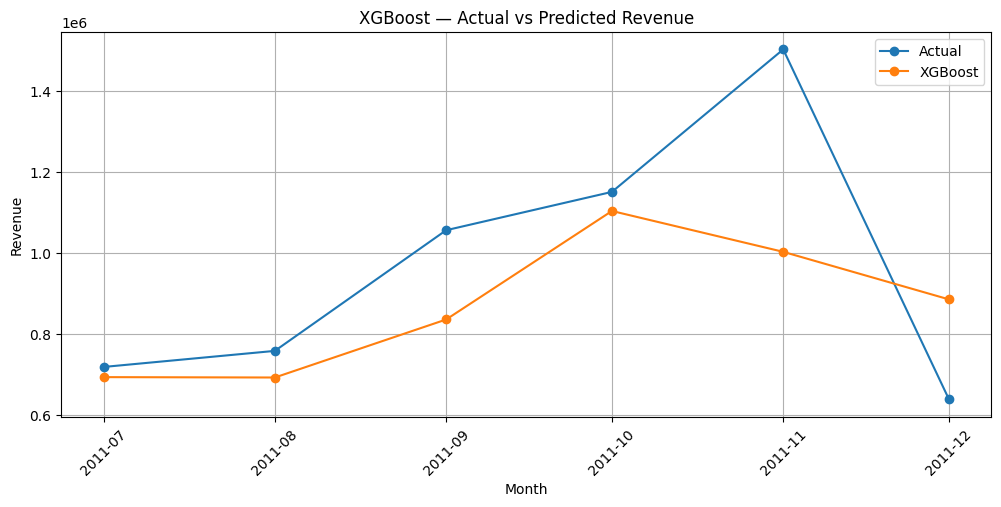

In [112]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_ml["InvoiceDate"],
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    test_ml["InvoiceDate"],
    xgb_pred,
    marker="o",
    label="XGBoost"
)

plt.title("XGBoost — Actual vs Predicted Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### **LightGBM Model**

In [113]:
lgb_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    num_leaves=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

lgb_pred = lgb_model.predict(X_test)

lgb_result = evaluate_model(
    "LightGBM",
    y_test,
    lgb_pred
)

lgb_result

{'Model': 'LightGBM',
 'MAE': 266306.64516666665,
 'RMSE': np.float64(344066.07405500306),
 'MAPE': np.float64(24.132912148572476)}

### **LightGBM Forecast**

In [114]:
lgb_forecast = test_ml[
    ["InvoiceDate", "Revenue"]
].copy()

lgb_forecast["Predicted_Revenue"] = lgb_pred

display(lgb_forecast)

,InvoiceDate,Revenue,Predicted_Revenue
13,2011-07-01,718076.121,804486.860577
14,2011-08-01,757841.380,804486.860577
15,2011-09-01,1056435.192,804486.860577
16,2011-10-01,1151263.730,804486.860577
17,2011-11-01,1503866.780,804486.860577
18,2011-12-01,637808.330,804486.860577


### **LightGBM Plot**

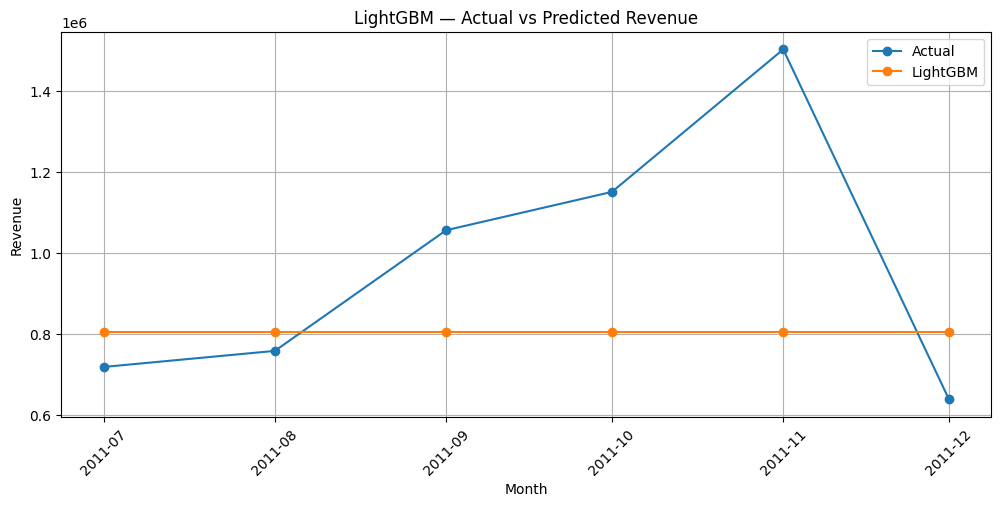

In [115]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_ml["InvoiceDate"],
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    test_ml["InvoiceDate"],
    lgb_pred,
    marker="o",
    label="LightGBM"
)

plt.title("LightGBM — Actual vs Predicted Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### **ARIMA**

In [116]:
sales_series = (
    monthly_ml
    .set_index("InvoiceDate")["Revenue"]
    .sort_index()
)

train_series = sales_series.iloc[:-test_months]

test_series = sales_series.iloc[-test_months:]

print("Training observations:", len(train_series))
print("Testing observations:", len(test_series))

Training observations: 19
Testing observations: 6


In [117]:
arima_model = ARIMA(
    train_series,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(test_series)
)

arima_pred = np.array(arima_pred)

arima_result = evaluate_model(
    "ARIMA",
    test_series.values,
    arima_pred
)

arima_result

{'Model': 'ARIMA',
 'MAE': 269737.4729818305,
 'RMSE': np.float64(374413.67698105436),
 'MAPE': np.float64(22.912079023036892)}

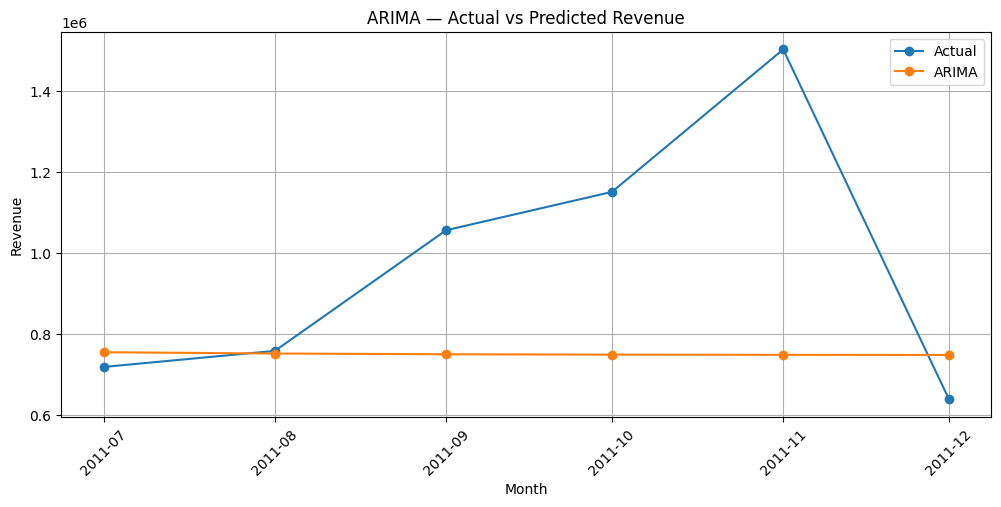

In [118]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_series.index,
    test_series.values,
    marker="o",
    label="Actual"
)

plt.plot(
    test_series.index,
    arima_pred,
    marker="o",
    label="ARIMA"
)

plt.title("ARIMA — Actual vs Predicted Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### **SARIMA**

In [119]:
try:

    sarima_model = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_fit = sarima_model.fit(
        disp=False
    )

    sarima_pred = sarima_fit.forecast(
        steps=len(test_series)
    )

    sarima_pred = np.array(sarima_pred)

    sarima_result = evaluate_model(
        "SARIMA",
        test_series.values,
        sarima_pred
    )

    print(sarima_result)

except Exception as e:

    print("SARIMA could not be fitted.")
    print("Reason:", e)

    sarima_pred = np.full(
        len(test_series),
        np.nan
    )

    sarima_result = {
        "Model": "SARIMA",
        "MAE": np.nan,
        "RMSE": np.nan,
        "MAPE": np.nan
    }

{'Model': 'SARIMA', 'MAE': 76676.83382145996, 'RMSE': np.float64(101327.11275581947), 'MAPE': np.float64(9.93539168986555)}


### **SARIMA Plot**

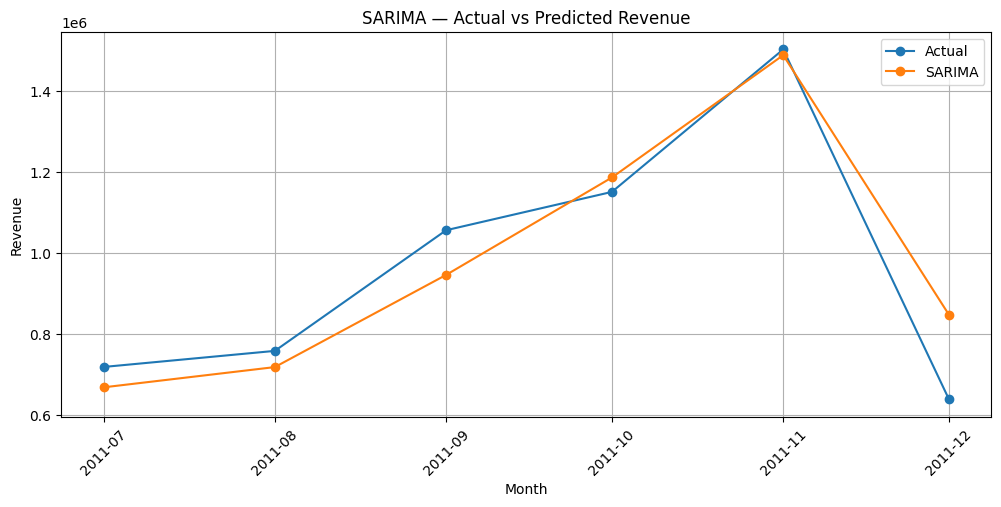

In [120]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_series.index,
    test_series.values,
    marker="o",
    label="Actual"
)

plt.plot(
    test_series.index,
    sarima_pred,
    marker="o",
    label="SARIMA"
)

plt.title("SARIMA — Actual vs Predicted Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### **Prophet Model**

In [121]:
prophet_train = pd.DataFrame({
    "ds": train_series.index,
    "y": train_series.values
})

prophet_train.head()

,ds,y
0,2009-12-01,822483.950
1,2010-01-01,651155.112
2,2010-02-01,551504.726
3,2010-03-01,830915.261
4,2010-04-01,678875.252


In [122]:

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(
    prophet_train
)

INFO:prophet:n_changepoints greater than number of observations. Using 14.


In [123]:
prophet_test_dates = pd.DataFrame({
    "ds": test_series.index
})

prophet_test_forecast = prophet_model.predict(
    prophet_test_dates
)

prophet_pred = prophet_test_forecast["yhat"].values

prophet_result = evaluate_model(
    "Prophet",
    test_series.values,
    prophet_pred
)

prophet_result

{'Model': 'Prophet',
 'MAE': 168535.2871705417,
 'RMSE': np.float64(178790.01583928685),
 'MAPE': np.float64(18.809162279985777)}

### **Prophet Plot**

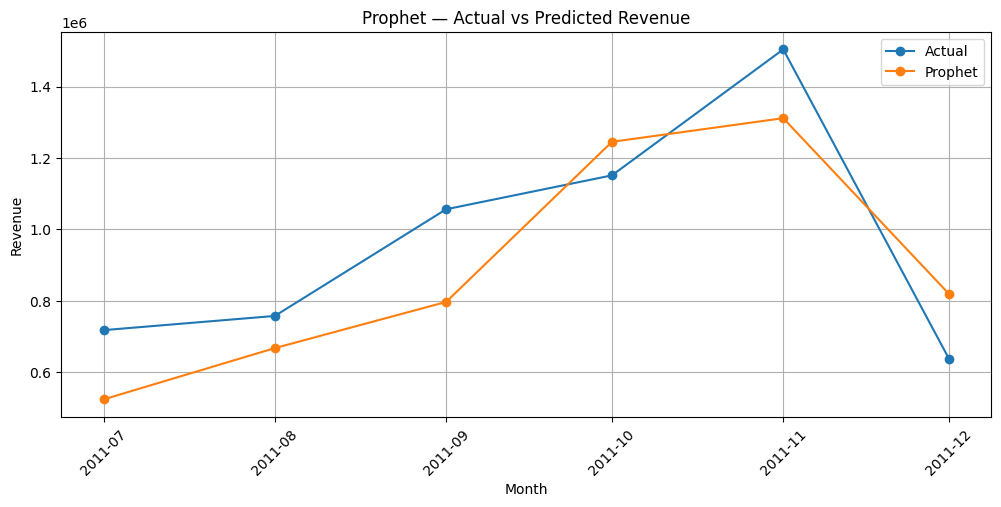

In [124]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_series.index,
    test_series.values,
    marker="o",
    label="Actual"
)

plt.plot(
    test_series.index,
    prophet_pred,
    marker="o",
    label="Prophet"
)

plt.title("Prophet — Actual vs Predicted Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### **Compare All ML + Statistical Models**

In [125]:
model_results = pd.DataFrame([
    rf_result,
    xgb_result,
    lgb_result,
    arima_result,
    sarima_result,
    prophet_result
])

model_results = model_results.sort_values(
    "MAPE"
).reset_index(drop=True)

display(model_results)

,Model,MAE,RMSE,MAPE
0,SARIMA,76676.833821,101327.112756,9.935392
1,XGBoost,184591.072583,247706.993310,18.219141
2,Prophet,168535.287171,178790.015839,18.809162
3,Random Forest,201565.886165,267653.873029,21.447901
4,ARIMA,269737.472982,374413.676981,22.912079
5,LightGBM,266306.645167,344066.074055,24.132912


### **Task 3 Baseline Results**

In [126]:
try:

    all_results = pd.concat(
        [
            baseline_results,
            model_results
        ],
        ignore_index=True
    )

except NameError:

    print("baseline_results was not found.")
    print("Showing Task 4 models only.")

    all_results = model_results.copy()

all_results = all_results.sort_values(
    "MAPE"
).reset_index(drop=True)

display(all_results)

,Model,MAE,RMSE,MAPE
0,SARIMA,76676.833821,101327.112756,9.935392
1,Seasonal Naive,83408.341667,101877.457945,10.501260
2,XGBoost,184591.072583,247706.993310,18.219141
3,Prophet,168535.287171,178790.015839,18.809162
4,Random Forest,201565.886165,267653.873029,21.447901
5,Naive,266306.645167,367334.890897,22.814809
6,ARIMA,269737.472982,374413.676981,22.912079
7,LightGBM,266306.645167,344066.074055,24.132912


### **Best Model**

In [127]:
valid_results = all_results.dropna(
    subset=["MAPE"]
).copy()

best_model = valid_results.iloc[0]["Model"]

best_mape = valid_results.iloc[0]["MAPE"]

print("Best Model:", best_model)
print(f"Best MAPE: {best_mape:.2f}%")

Best Model: SARIMA
Best MAPE: 9.94%


### **Complete Model Comparison Chart**

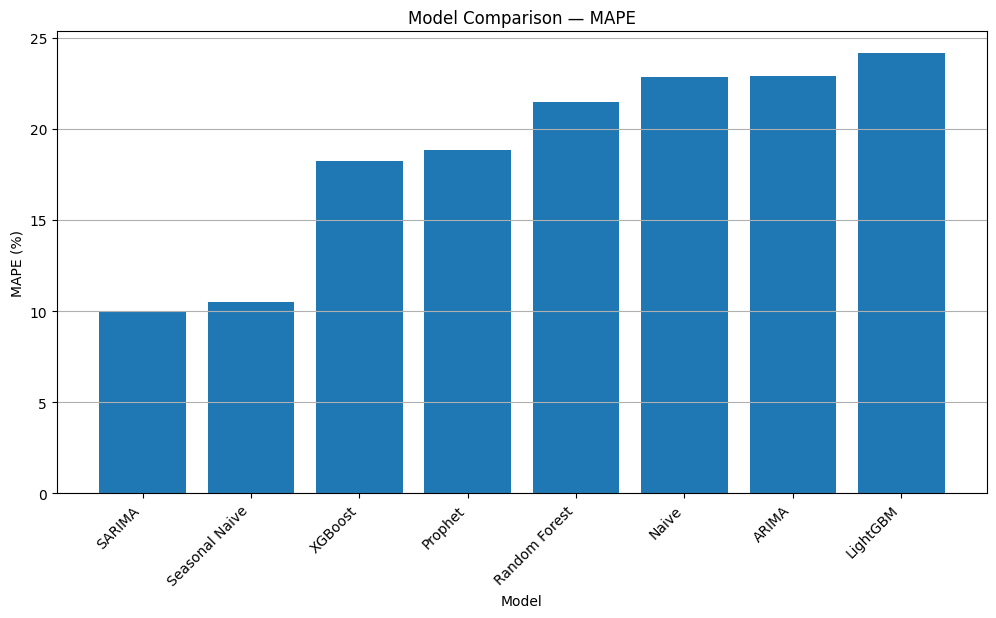

In [128]:
plt.figure(figsize=(12, 6))

plt.bar(
    all_results["Model"],
    all_results["MAPE"]
)

plt.title("Model Comparison — MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y"
)

plt.show()

### **Actual vs All ML Predictions**

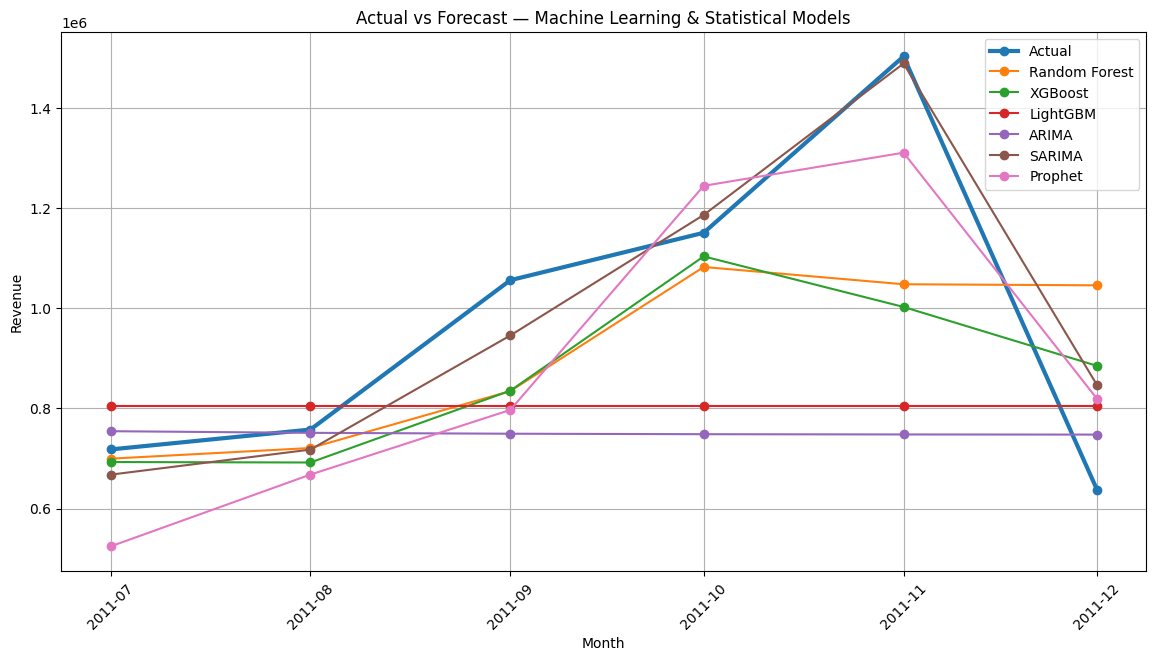

In [129]:
plt.figure(figsize=(14, 7))

plt.plot(
    test_series.index,
    test_series.values,
    marker="o",
    linewidth=3,
    label="Actual"
)

plt.plot(
    test_ml["InvoiceDate"],
    rf_pred,
    marker="o",
    label="Random Forest"
)

plt.plot(
    test_ml["InvoiceDate"],
    xgb_pred,
    marker="o",
    label="XGBoost"
)

plt.plot(
    test_ml["InvoiceDate"],
    lgb_pred,
    marker="o",
    label="LightGBM"
)

plt.plot(
    test_series.index,
    arima_pred,
    marker="o",
    label="ARIMA"
)

plt.plot(
    test_series.index,
    sarima_pred,
    marker="o",
    label="SARIMA"
)

plt.plot(
    test_series.index,
    prophet_pred,
    marker="o",
    label="Prophet"
)

plt.title(
    "Actual vs Forecast — Machine Learning & Statistical Models"
)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### **Feature Importance: Random Forest**

In [130]:
rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

display(rf_importance)

,Feature,Importance
6,month,0.494709
0,lag_1,0.169305
7,quarter,0.110579
3,lag_6,0.071934
2,lag_3,0.045876
4,rolling_mean_3,0.028430
8,time_index,0.027829
5,rolling_mean_6,0.026920
1,lag_2,0.024417


### **Feature Importance Plot**

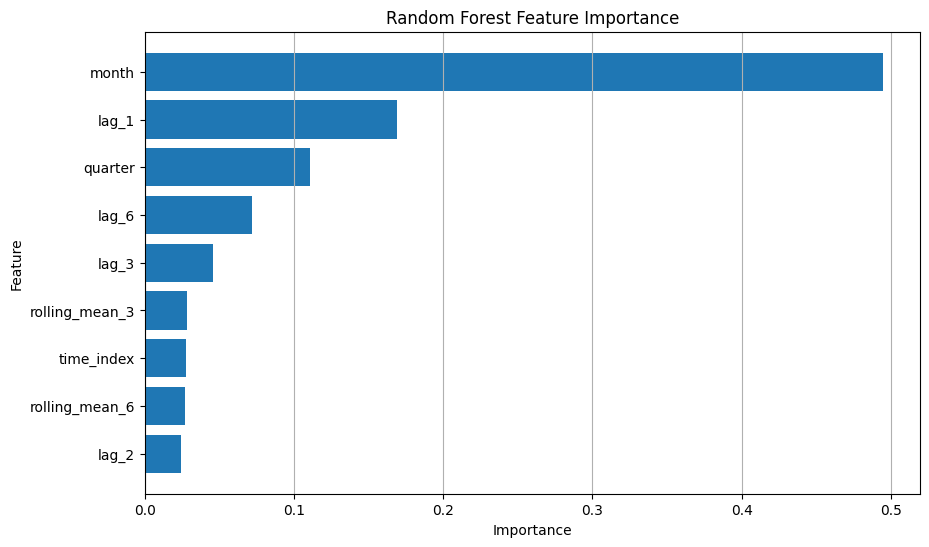

In [131]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.grid(
    axis="x"
)

plt.show()

### **Feature Importance: LightGBM**

In [132]:
lgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": lgb_model.feature_importances_
})

lgb_importance = lgb_importance.sort_values(
    "Importance",
    ascending=False
)

display(lgb_importance)

,Feature,Importance
0,lag_1,0
1,lag_2,0
2,lag_3,0
3,lag_6,0
4,rolling_mean_3,0
5,rolling_mean_6,0
6,month,0
7,quarter,0
8,time_index,0


### **Prepare 3-Month Future Dates**

In [133]:
last_date = sales_series.index.max()

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

print("Future forecast dates:")

for date in future_dates:
    print(date)

Future forecast dates:
2012-01-01 00:00:00
2012-02-01 00:00:00
2012-03-01 00:00:00


### **Future Forecast Using XGBoost**

In [134]:
history = list(sales_series.values)

future_xgb_predictions = []

for i, date in enumerate(future_dates):

    lag_1 = history[-1]
    lag_2 = history[-2]
    lag_3 = history[-3]
    lag_6 = history[-6]

    rolling_mean_3 = np.mean(
        history[-3:]
    )

    rolling_mean_6 = np.mean(
        history[-6:]
    )

    time_index = len(history)

    row = pd.DataFrame([{
        "lag_1": lag_1,
        "lag_2": lag_2,
        "lag_3": lag_3,
        "lag_6": lag_6,
        "rolling_mean_3": rolling_mean_3,
        "rolling_mean_6": rolling_mean_6,
        "month": date.month,
        "quarter": date.quarter,
        "time_index": time_index
    }])

    prediction = xgb_model.predict(
        row[features]
    )[0]

    future_xgb_predictions.append(
        prediction
    )

    history.append(
        prediction
    )

### **Display XGBoost Future Forecast**

In [135]:
future_xgb_df = pd.DataFrame({
    "Forecast_Month": future_dates,
    "Forecast_Revenue": future_xgb_predictions
})

display(future_xgb_df)

,Forecast_Month,Forecast_Revenue
0,2012-01-01,663675.3125
1,2012-02-01,664162.6875
2,2012-03-01,666598.7500


### **Future Forecast Using Random Forest**

In [136]:
history = list(sales_series.values)

future_rf_predictions = []

for date in future_dates:

    row = pd.DataFrame([{
        "lag_1": history[-1],
        "lag_2": history[-2],
        "lag_3": history[-3],
        "lag_6": history[-6],
        "rolling_mean_3": np.mean(history[-3:]),
        "rolling_mean_6": np.mean(history[-6:]),
        "month": date.month,
        "quarter": date.quarter,
        "time_index": len(history)
    }])

    prediction = rf_model.predict(
        row[features]
    )[0]

    future_rf_predictions.append(
        prediction
    )

    history.append(
        prediction
    )

### **Future Forecast Using LightGBM**

In [137]:
history = list(sales_series.values)

future_lgb_predictions = []

for date in future_dates:

    row = pd.DataFrame([{
        "lag_1": history[-1],
        "lag_2": history[-2],
        "lag_3": history[-3],
        "lag_6": history[-6],
        "rolling_mean_3": np.mean(history[-3:]),
        "rolling_mean_6": np.mean(history[-6:]),
        "month": date.month,
        "quarter": date.quarter,
        "time_index": len(history)
    }])

    prediction = lgb_model.predict(
        row[features]
    )[0]

    future_lgb_predictions.append(
        prediction
    )

    history.append(
        prediction
    )

### **ARIMA Future Forecast**

In [138]:
arima_full_model = ARIMA(
    sales_series,
    order=(1, 1, 1)
)

arima_full_fit = arima_full_model.fit()

future_arima = arima_full_fit.forecast(
    steps=3
)

future_arima = np.array(
    future_arima
)

future_arima

array([751241.11381251, 804134.53063858, 828798.59555442])

### **SARIMA Future Forecast**

In [139]:
try:

    sarima_full_model = SARIMAX(
        sales_series,
        order=(1, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_full_fit = sarima_full_model.fit(
        disp=False
    )

    future_sarima = sarima_full_fit.forecast(
        steps=3
    )

    future_sarima = np.array(
        future_sarima
    )

except Exception as e:

    print("SARIMA future forecast unavailable.")
    print(e)

    future_sarima = np.array([
        np.nan,
        np.nan,
        np.nan
    ])

### **Prophet Future Forecast**

In [140]:
future_prophet_dates = pd.DataFrame({
    "ds": future_dates
})

prophet_future = prophet_model.predict(
    future_prophet_dates
)

future_prophet = prophet_future[
    "yhat"
].values

future_prophet

array([726474.55986458, 491385.26815317, 894606.68542417])

### **Combine All Future Forecasts**

In [141]:
future_forecasts = pd.DataFrame({
    "Forecast_Month": future_dates,
    "Random_Forest": future_rf_predictions,
    "XGBoost": future_xgb_predictions,
    "LightGBM": future_lgb_predictions,
    "ARIMA": future_arima,
    "SARIMA": future_sarima,
    "Prophet": future_prophet
})

display(future_forecasts)

,Forecast_Month,Random_Forest,XGBoost,LightGBM,ARIMA,SARIMA,Prophet
0,2012-01-01,674093.448732,663675.3125,804486.860577,751241.113813,640415.936872,726474.559865
1,2012-02-01,650171.784754,664162.6875,804486.860577,804134.530639,354210.589000,491385.268153
2,2012-03-01,687423.726879,666598.7500,804486.860577,828798.595554,653256.011421,894606.685424


### **Future Forecast Visualization**

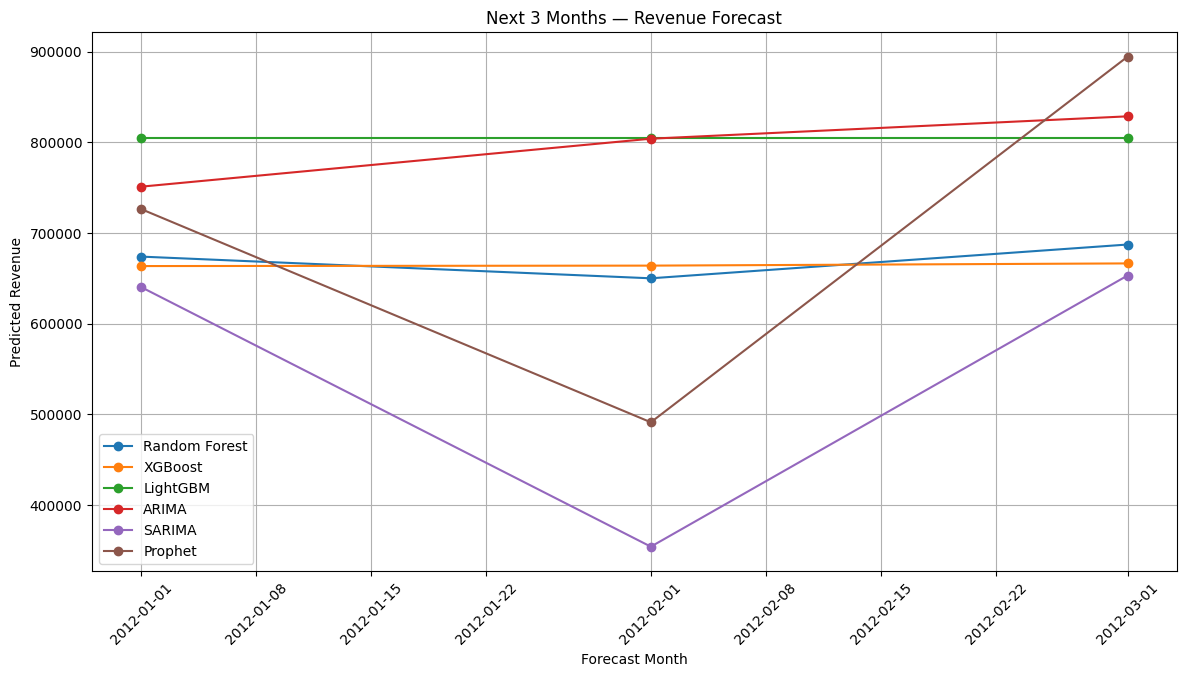

In [142]:
plt.figure(figsize=(14, 7))

plt.plot(
    future_forecasts["Forecast_Month"],
    future_forecasts["Random_Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    future_forecasts["Forecast_Month"],
    future_forecasts["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.plot(
    future_forecasts["Forecast_Month"],
    future_forecasts["LightGBM"],
    marker="o",
    label="LightGBM"
)

plt.plot(
    future_forecasts["Forecast_Month"],
    future_forecasts["ARIMA"],
    marker="o",
    label="ARIMA"
)

plt.plot(
    future_forecasts["Forecast_Month"],
    future_forecasts["SARIMA"],
    marker="o",
    label="SARIMA"
)

plt.plot(
    future_forecasts["Forecast_Month"],
    future_forecasts["Prophet"],
    marker="o",
    label="Prophet"
)

plt.title("Next 3 Months — Revenue Forecast")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Revenue")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### **Save Model Evaluation Results**

In [143]:
all_results.to_csv(
    "model_evaluation_results.csv",
    index=False
)

print(
    "Saved: model_evaluation_results.csv"
)

Saved: model_evaluation_results.csv


### **Save Future Forecasts**

In [144]:
future_forecasts.to_csv(
    "future_revenue_forecasts.csv",
    index=False
)

print(
    "Saved: future_revenue_forecasts.csv"
)

Saved: future_revenue_forecasts.csv


### **Final Task 4 Summary**

In [145]:
print("=" * 60)
print("TASK 4 — MACHINE LEARNING FORECASTING SUMMARY")
print("=" * 60)

print("\nModels Evaluated:")
for model in all_results["Model"]:
    print("-", model)

print("\nBest Model:")
print(best_model)

print(f"\nBest MAPE: {best_mape:.2f}%")

print("\nFuture Forecast:")
display(future_forecasts)

print("\nFiles Generated:")
print("1. model_evaluation_results.csv")
print("2. future_revenue_forecasts.csv")

TASK 4 — MACHINE LEARNING FORECASTING SUMMARY

Models Evaluated:
- SARIMA
- Seasonal Naive
- XGBoost
- Prophet
- Random Forest
- Naive
- ARIMA
- LightGBM

Best Model:
SARIMA

Best MAPE: 9.94%

Future Forecast:


,Forecast_Month,Random_Forest,XGBoost,LightGBM,ARIMA,SARIMA,Prophet
0,2012-01-01,674093.448732,663675.3125,804486.860577,751241.113813,640415.936872,726474.559865
1,2012-02-01,650171.784754,664162.6875,804486.860577,804134.530639,354210.589000,491385.268153
2,2012-03-01,687423.726879,666598.7500,804486.860577,828798.595554,653256.011421,894606.685424



Files Generated:
1. model_evaluation_results.csv
2. future_revenue_forecasts.csv
